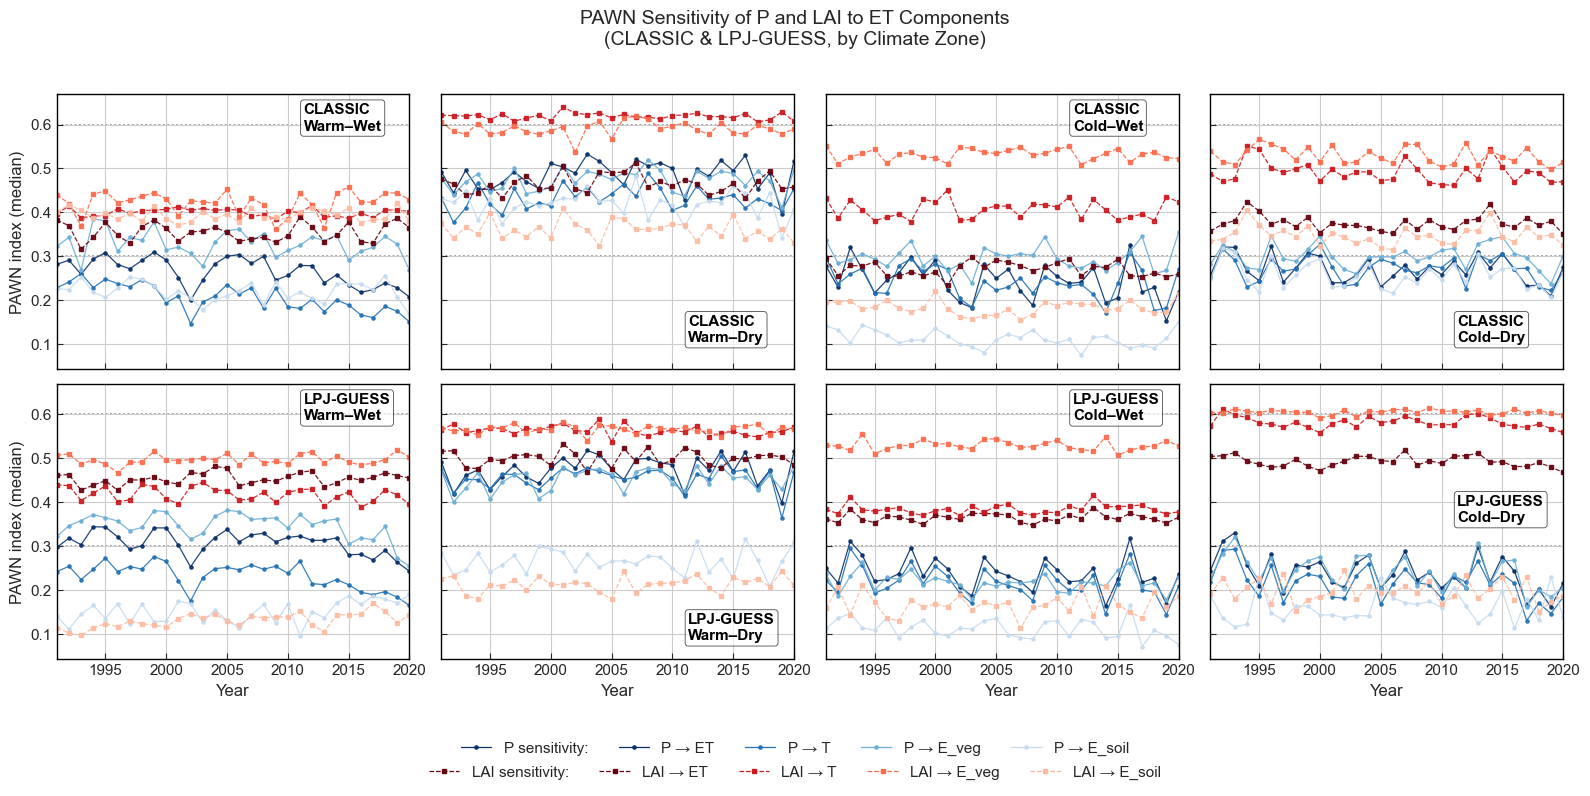

In [1]:
# -*- coding: utf-8 -*-
"""
2×4 图：
第一行：CLASSIC 四个气候区
第二行：LPJ-GUESS 四个气候区
每图 8 条折线：P→蓝色系, LAI→绿色系
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ========== 1. 读入数据 ==========
df = pd.read_csv("./output/30y_pawn/all_30y_pawn_results.csv")

# 统一类型
df["year"] = df["year"].astype(int)
df = df[df["input_var"].isin(["precipitation", "lai"])]

# ========== 2. 定义参数 ==========
models = ["CLASSIC", "LPJ-GUESS"]
zones = ["HW", "HD", "CW", "CD"]
outputs = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

zone_titles = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}


# ========= 3. 配色方案 =========

# ========= 3. 配色方案 =========
# blues = plt.cm.Blues(np.linspace(0.4, 0.8, len(outputs)))[::-1]
# reds  = plt.cm.Reds(np.linspace(0.4, 0.8, len(outputs)))[::-1]


# ========= 3. 配色方案（更易区分） =========
# 顺序对应 label_order = [ET, T, E_veg, E_soil]
# P：蓝色系
blues = [
    "#08306b",  # ET：最深蓝
    "#2171b5",  # T
    "#6baed6",  # E_veg
    "#c6dbef",  # E_soil：最浅蓝
]

# LAI：红色系
reds = [
    "#67000d",  # ET：最深红
    "#cb181d",  # T
    "#fb6a4a",  # E_veg
    "#fcbba1",  # E_soil：最浅红
]

label_order = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]


label_order = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

label_map_P = {
    "evapotrans": "P → ET",
    "tran": "P → T",
    "evspsblveg": "P → E_veg",
    "evspsblsoi": "P → E_soil",
}
label_map_L = {
    "evapotrans": "LAI → ET",
    "tran": "LAI → T",
    "evspsblveg": "LAI → E_veg",
    "evspsblsoi": "LAI → E_soil",
}

# ========= 4. 样式设置 =========
mpl.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 5. 创建图形 =========
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True, sharex='col')
plt.subplots_adjust(wspace=0.25, hspace=0.3)

xlim_min, xlim_max = df["year"].min(), df["year"].max()

for i, model in enumerate(models):
    for j, zone in enumerate(zones):
        ax = axes[i, j]
        sub = df[(df["model"] == model) & (df["climate_zone"] == zone)]

        # ---- P 蓝色 ----
        for k, out in enumerate(label_order):
            s = sub[(sub["input_var"] == "precipitation") & (sub["output_var"] == out)].sort_values("year")
            if not s.empty:
                ax.plot(s["year"], s["pawn_median"],
                        color=blues[k], lw=0.9, marker="o", ms=2.3,
                        alpha=0.9, label=label_map_P[out])

        # ---- LAI 红色 ----
        for k, out in enumerate(label_order):
            s = sub[(sub["input_var"] == "lai") & (sub["output_var"] == out)].sort_values("year")
            if not s.empty:
                ax.plot(s["year"], s["pawn_median"],
                        color=reds[k], lw=0.9, marker="s", ms=2.3,
                        alpha=0.9, linestyle="--", label=label_map_L[out])

        # ---- 坐标样式 ----
        ax.set_xlim(xlim_min, xlim_max)
        ax.tick_params(direction="in", length=4, width=0.8)
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(1.0)
            spine.set_visible(True)

        # y轴标签
        if j == 0:
            ax.set_ylabel("PAWN index (median)")

        # x轴：第一行不显示年份
        if i == 0:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel("Year")

        # ---- 智能放置标题 ----
        # ---- 手动指定各子图的 label 位置（轴坐标 0~1）----
        # 先定义一个字典：(model, zone) -> (xfrac, yfrac)
        label_pos = {
            ("CLASSIC",   "HW"): (0.7,  0.87),
            ("CLASSIC",   "HD"): (0.70, 0.1),
            ("CLASSIC",   "CW"): (0.7, 0.87),
            ("CLASSIC",   "CD"): (0.70,  0.1),
            ("LPJ-GUESS", "HW"): (0.7,  0.87),
            ("LPJ-GUESS", "HD"): (0.70, 0.07),
            ("LPJ-GUESS", "CW"): (0.7,  0.87),
            ("LPJ-GUESS", "CD"): (0.70, 0.5),
        }

        # 如果没在字典里，就用一个默认位置
        xfrac, yfrac = label_pos.get((model, zone), (0.15, 0.8))

        ax.text(xfrac, yfrac,
                f"{model}\n{zone_titles.get(zone, zone)}",
                transform=ax.transAxes,          # ★ 轴坐标，和数据范围无关
                fontsize=11, fontweight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black",
                          lw=0.6, alpha=0.7))

                # ---- 添加参考线 y=0.3 和 y=0.6 ----
        # ---- 参考线：y = 0.3 和 y = 0.6（更醒目版本） ----
        for yref in [0.3, 0.6]:
            ax.axhline(
                y=yref,
                color="dimgray",       # 改为纯黑线
                lw=1.2,              # 稍微加粗
                ls=":",             # 用短虚线，比点线清晰
                alpha=0.8,           # 稍微降低透明度（更实）
                zorder=0
            )

     


# ========= 6. 图例（手动构造，确保包含 E_soil） =========
from matplotlib.lines import Line2D

# 和 label_order 一一对应：evapotrans, tran, evspsblveg, evspsblsoi
handles_P = [
    Line2D([], [], color=blues[0], lw=0.9, marker="o", ms=2.3),  # P → ET
    Line2D([], [], color=blues[1], lw=0.9, marker="o", ms=2.3),  # P → T
    Line2D([], [], color=blues[2], lw=0.9, marker="o", ms=2.3),  # P → E_veg
    Line2D([], [], color=blues[3], lw=0.9, marker="o", ms=2.3),  # P → E_soil
]

handles_L = [
    Line2D([], [], color=reds[0], lw=0.9, marker="s", ms=2.3, linestyle="--"),  # LAI → ET
    Line2D([], [], color=reds[1], lw=0.9, marker="s", ms=2.3, linestyle="--"),  # LAI → T
    Line2D([], [], color=reds[2], lw=0.9, marker="s", ms=2.3, linestyle="--"),  # LAI → E_veg
    Line2D([], [], color=reds[3], lw=0.9, marker="s", ms=2.3, linestyle="--"),  # LAI → E_soil
]

labels_P = ["P sensitivity:", "P → ET", "P → T", "P → E_veg", "P → E_soil"]
labels_L = ["LAI sensitivity:", "LAI → ET", "LAI → T", "LAI → E_veg", "LAI → E_soil"]

# 为了在第一列写“P sensitivity:”/“LAI sensitivity:”，前面加一个“头”句柄
handle_P_header = Line2D([], [], color=blues[0], lw=0.9, marker="o", ms=2.3)
handle_L_header = Line2D([], [], color=reds[0], lw=0.9, marker="s", ms=2.3, linestyle="--")

fig.legend(
    [handle_P_header] + handles_P,
    labels_P,
    loc="lower center", ncol=5, fontsize=11, frameon=False,
    bbox_to_anchor=(0.5, 0.02),
)

fig.legend(
    [handle_L_header] + handles_L,
    labels_L,
    loc="lower center", ncol=5, fontsize=11, frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)
# ========= 7. 总标题 =========
fig.suptitle("PAWN Sensitivity of P and LAI to ET Components\n(CLASSIC & LPJ-GUESS, by Climate Zone)",
             fontsize=14, y=0.97)
plt.tight_layout(rect=[0, 0.09, 1, 0.95])
plt.show()

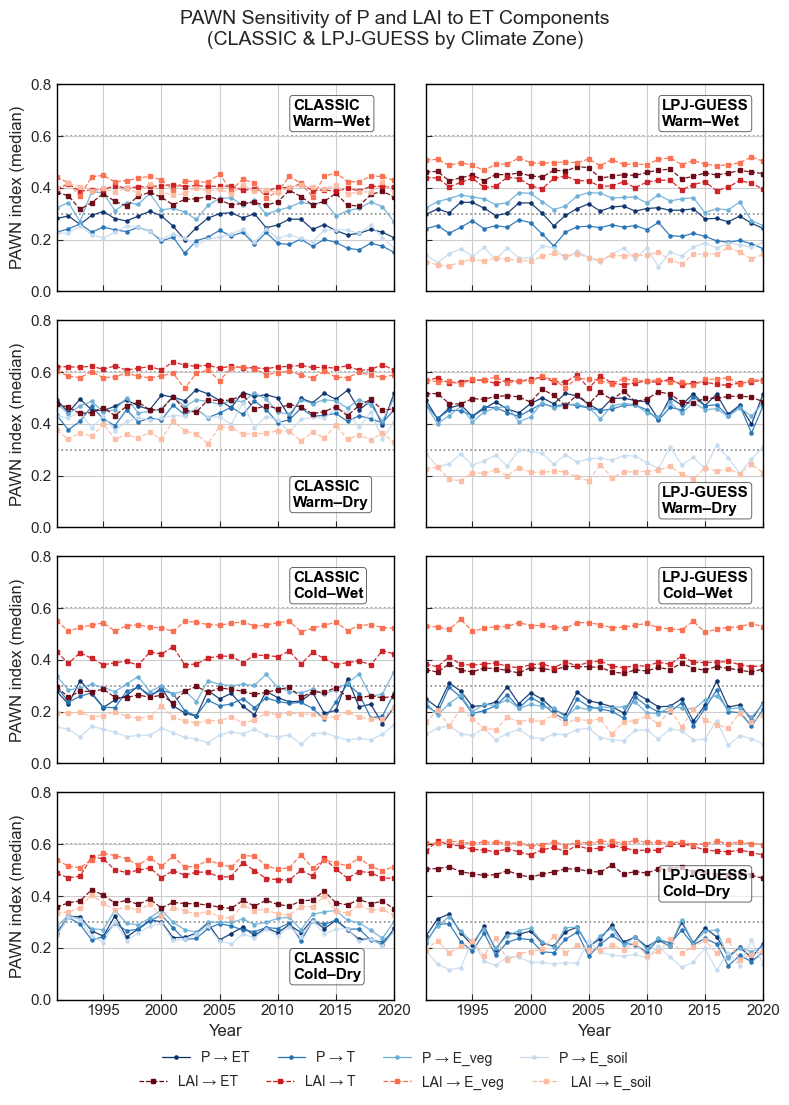

In [2]:
# -*- coding: utf-8 -*-
"""
4×2 图：
每行：一个气候区（HW, HD, CW, CD）
左列：CLASSIC
右列：LPJ-GUESS
保持每个子图 label 位置不变。
y轴范围与示例图一致（0–0.8，间隔0.2）
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.lines import Line2D

# ========== 1. 读入数据 ==========
df = pd.read_csv("./output/30y_pawn/all_30y_pawn_results.csv")

df["year"] = df["year"].astype(int)
df = df[df["input_var"].isin(["precipitation", "lai"])]

# ========== 2. 定义参数 ==========
models = ["CLASSIC", "LPJ-GUESS"]
zones = ["HW", "HD", "CW", "CD"]
outputs = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

zone_titles = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}

# ========= 3. 配色方案 =========
blues = ["#08306b", "#2171b5", "#6baed6", "#c6dbef"]  # P
reds = ["#67000d", "#cb181d", "#fb6a4a", "#fcbba1"]  # LAI

label_order = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

label_map_P = {
    "evapotrans": "P → ET",
    "tran": "P → T",
    "evspsblveg": "P → E_veg",
    "evspsblsoi": "P → E_soil",
}
label_map_L = {
    "evapotrans": "LAI → ET",
    "tran": "LAI → T",
    "evspsblveg": "LAI → E_veg",
    "evspsblsoi": "LAI → E_soil",
}

# ========= 4. 样式 =========
mpl.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 5. 绘图 (4×2) =========
fig, axes = plt.subplots(4, 2, figsize=(8, 12), sharey=True, sharex='col')
plt.subplots_adjust(wspace=0.25, hspace=0.3)

xlim_min, xlim_max = df["year"].min(), df["year"].max()

for i, zone in enumerate(zones):        # 4 行 → zone
    for j, model in enumerate(models):  # 2 列 → model
        ax = axes[i, j]
        sub = df[(df["model"] == model) & (df["climate_zone"] == zone)]

        # ---- P 蓝色 ----
        for k, out in enumerate(label_order):
            s = sub[(sub["input_var"] == "precipitation") & (sub["output_var"] == out)].sort_values("year")
            if not s.empty:
                ax.plot(s["year"], s["pawn_median"],
                        color=blues[k], lw=0.9, marker="o", ms=2.3,
                        alpha=0.9, label=label_map_P[out])

        # ---- LAI 红色 ----
        for k, out in enumerate(label_order):
            s = sub[(sub["input_var"] == "lai") & (sub["output_var"] == out)].sort_values("year")
            if not s.empty:
                ax.plot(s["year"], s["pawn_median"],
                        color=reds[k], lw=0.9, marker="s", ms=2.3,
                        alpha=0.9, linestyle="--", label=label_map_L[out])

        # ---- 坐标轴样式 ----
        ax.set_xlim(xlim_min, xlim_max)
        ax.set_ylim(0, 0.8)                          # ✅ 固定 y 轴范围
        ax.set_yticks(np.arange(0, 0.81, 0.2))       # ✅ 间隔 0.2
        ax.tick_params(direction="in", length=4, width=0.8)
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(1.0)

        # y轴
        if j == 0:
            ax.set_ylabel("PAWN index (median)")     # ✅ 更新标签名与示例一致
        else:
            ax.set_ylabel("")

        # x轴
        if i == 3:
            ax.set_xlabel("Year")
        else:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)

        # ---- label 位置保持不变 ----
        label_pos = {
            ("CLASSIC",   "HW"): (0.7,  0.8),
            ("CLASSIC",   "HD"): (0.70, 0.1),
            ("CLASSIC",   "CW"): (0.7, 0.8),
            ("CLASSIC",   "CD"): (0.70,  0.1),
            ("LPJ-GUESS", "HW"): (0.7,  0.8),
            ("LPJ-GUESS", "HD"): (0.70, 0.07),
            ("LPJ-GUESS", "CW"): (0.7,  0.8),
            ("LPJ-GUESS", "CD"): (0.70, 0.5),
        }
        xfrac, yfrac = label_pos.get((model, zone), (0.15, 0.8))

        ax.text(xfrac, yfrac,
                f"{model}\n{zone_titles.get(zone, zone)}",
                transform=ax.transAxes,
                fontsize=11, fontweight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black",
                          lw=0.6, alpha=0.7))

        # ---- 参考线 ----
        for yref in [0.3, 0.6]:
            ax.axhline(y=yref, color="dimgray", lw=1.2, ls=":", alpha=0.8, zorder=0)

# ========= 6. 图例 =========
handles_P = [Line2D([], [], color=blues[k], lw=0.9, marker="o", ms=2.3) for k in range(4)]
handles_L = [Line2D([], [], color=reds[k], lw=0.9, marker="s", ms=2.3, linestyle="--") for k in range(4)]

labels_P = ["P → ET", "P → T", "P → E_veg", "P → E_soil"]
labels_L = ["LAI → ET", "LAI → T", "LAI → E_veg", "LAI → E_soil"]

fig.legend(handles_P, labels_P, loc="lower center", ncol=4, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, 0.06))
fig.legend(handles_L, labels_L, loc="lower center", ncol=4, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, 0.04))

# ========= 7. 总标题 =========
fig.suptitle("PAWN Sensitivity of P and LAI to ET Components\n(CLASSIC & LPJ-GUESS by Climate Zone)",
             fontsize=14, y=0.95)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

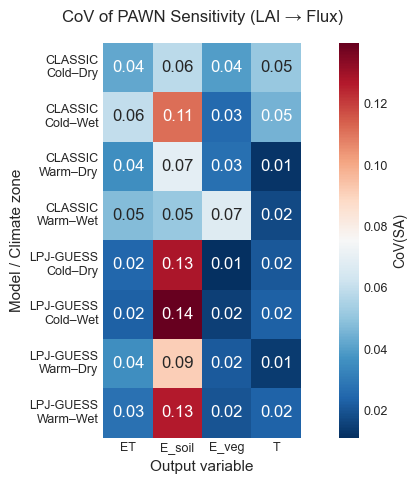

In [126]:
# -*- coding: utf-8 -*-
"""
绘制 P 或 LAI 对各通量敏感度的 CoV 热力图
横轴：输出变量（ET, T, E_veg, E_soil）
纵轴：模型 × 气候区（Warm–Wet, Warm–Dry, Cold–Wet, Cold–Dry）
颜色：CoV_SA（逐年 PAWN 的变异系数）
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ========= 0. 选择要画的是 P 还是 LAI =========
# "precipitation" 或 "lai"
# target_input = "precipitation"
target_input = "lai"

# ========= 1. 读取逐年 PAWN 结果 =========
df = pd.read_csv("./output/30y_pawn/all_30y_pawn_results.csv")
df["year"] = df["year"].astype(int)

# 只保留 P 和 LAI
df = df[df["input_var"].isin(["precipitation", "lai"])]

# ========= 2. 计算逐年 PAWN 的 mean_SA 和 CoV_SA =========
group_cols = ["model", "climate_zone", "output_var", "input_var"]
rows = []

for keys, sub in df.groupby(group_cols):
    model, zone, outvar, inp = keys
    vals = sub["pawn_median"].dropna().values

    if len(vals) > 1:
        mean_sa = vals.mean()
        std_sa  = vals.std(ddof=1)
        cov_sa  = std_sa / mean_sa if mean_sa != 0 else np.nan
    else:
        mean_sa, cov_sa = np.nan, np.nan

    rows.append({
        "model": model,
        "climate_zone": zone,
        "output_var": outvar,
        "input_var": inp,
        "mean_SA": mean_sa,
        "CoV_SA": cov_sa,
        "n_years": len(vals)
    })

cov_df = pd.DataFrame(rows)

# 只选定一个输入变量（P 或 LAI）
cov_df = cov_df[cov_df["input_var"] == target_input]

# ========= 3. 构建热力图矩阵 =========
# 输出变量重命名
out_label_map = {
    "evapotrans": "ET",
    "tran": "T",
    "evspsblveg": "E_veg",
    "evspsblsoi": "E_soil",
}
cov_df["output_label"] = cov_df["output_var"].map(out_label_map)

pivot = cov_df.pivot_table(
    index=["model", "climate_zone"],
    columns="output_label",
    values="CoV_SA"
)

# 气候区全名
zone_fullname = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}
pivot.index = [f"{m}\n{zone_fullname.get(z, z)}" for (m, z) in pivot.index]

# 确保列顺序是 ET, E_soil, E_veg, T（跟你那张图类似）
desired_cols = ["ET", "E_soil", "E_veg", "T"]
pivot = pivot.reindex(columns=desired_cols)

# ========= 4. 绘制热力图 =========
plt.figure(figsize=(8, 5))
ax = sns.heatmap(
    pivot,
    annot=True, fmt=".2f",
    cmap="RdBu_r",        # CoV >= 0，用单向色带比较自然
    square=True,
    cbar_kws={"label": "CoV(SA)"},
    linewidths=0          # 去掉单元格边框
)

# ========= 5. 美化细节 =========
ax.set_xlabel("Output variable", fontsize=11)
ax.set_ylabel("Model / Climate zone", fontsize=11)

title_input = "P" if target_input == "precipitation" else "LAI"
ax.set_title(f"CoV of PAWN Sensitivity ({title_input} → Flux)", fontsize=12, pad=15)

# 调整 tick 字体
for label in ax.get_yticklabels():
    label.set_fontsize(9)
for label in ax.get_xticklabels():
    label.set_fontsize(9)

# 修改颜色条字体
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)
cbar.set_label("CoV(SA)", fontsize=10)

# 去掉四周外框
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

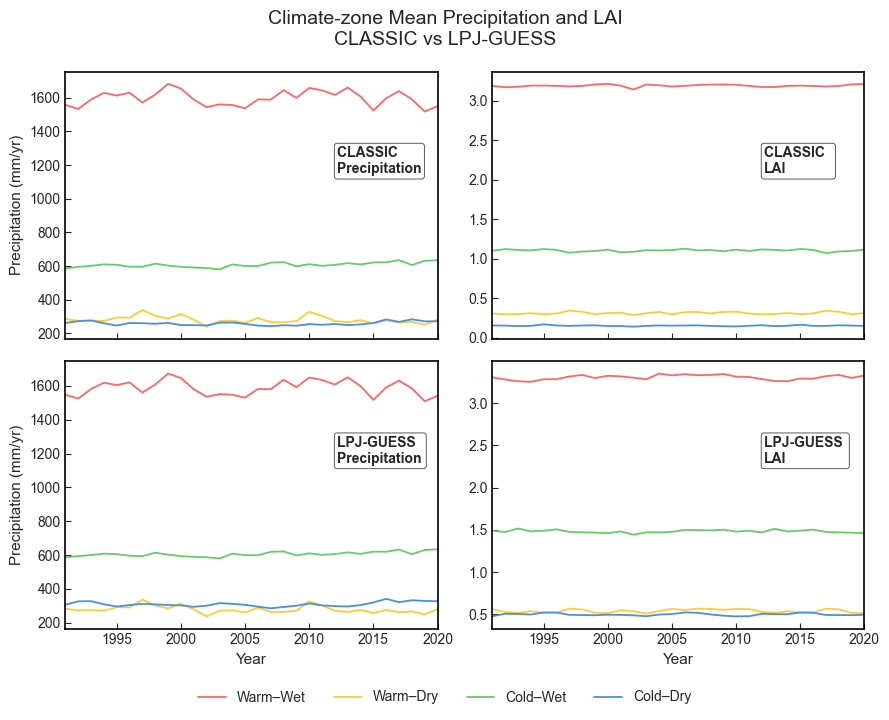

In [79]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path

sns.set_style("ticks")

# ========== 1. 读数据 ==========
classic_path = Path("data/preprocessed/preprocessed_with_zones/classic_with_climate_zones_30y.csv")
lpj_path     = Path("data/preprocessed/preprocessed_with_zones/lpj_guess_with_climate_zones_30y.csv")

classic = pd.read_csv(classic_path)
lpj     = pd.read_csv(lpj_path)

cols = ["time", "precipitation", "lai", "climate_zone"]
classic = classic[cols].dropna()
lpj     = lpj[cols].dropna()

classic["time"] = classic["time"].astype(int)
lpj["time"]     = lpj["time"].astype(int)

# ========== 2. 按年份与分区取平均 ==========
def agg(df):
    return df.groupby(["time", "climate_zone"])[["precipitation", "lai"]].mean().reset_index()

classic_agg = agg(classic)
lpj_agg     = agg(lpj)

# ========== 3. 分区颜色 ==========
zones = ["HW", "HD", "CW", "CD"]
zone_labels = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}
zone_colors = {
    "HW": "#ff6666",  # 红
    "HD": "#ffcc33",  # 黄
    "CW": "#66cc66",  # 绿
    "CD": "#4a90e2",  # 蓝
}

# ========== 4. 样式 ==========
mpl.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ========== 5. 2×2 图 ==========
fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True)
plt.subplots_adjust(wspace=0.25, hspace=0.3)

year_min = min(classic_agg["time"].min(), lpj_agg["time"].min())
year_max = max(classic_agg["time"].max(), lpj_agg["time"].max())

def plot_panel(ax, df, var, title, ylabel=False, xlabel=False):
    for z in zones:
        sub = df[df["climate_zone"] == z].sort_values("time")
        ax.plot(
            sub["time"], sub[var],
            color=zone_colors[z],
            lw=1.3,
            label=zone_labels[z]
        )
    ax.set_xlim(year_min, year_max)
    if ylabel:
        ax.set_ylabel("Precipitation (mm/yr)" if var == "precipitation" else "LAI")
    if xlabel:
        ax.set_xlabel("Year")
    ax.tick_params(direction="in", length=4, width=0.8)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.2)
    # 在图内标注模型与变量
    ax.text(0.73, 0.62, title, transform=ax.transAxes,
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=0.6, alpha=0.75))

# 第一行 CLASSIC
plot_panel(axes[0,0], classic_agg, "precipitation", "CLASSIC \nPrecipitation", ylabel=True)
plot_panel(axes[0,1], classic_agg, "lai", "CLASSIC  \nLAI")

# 第二行 LPJ-GUESS
plot_panel(axes[1,0], lpj_agg, "precipitation", "LPJ-GUESS  \nPrecipitation", ylabel=True, xlabel=True)
plot_panel(axes[1,1], lpj_agg, "lai", "LPJ-GUESS \nLAI", xlabel=True)

# ========== 6. 图例 ==========
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center", ncol=4, frameon=False,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

# ========== 7. 总标题 ==========
fig.suptitle("Climate-zone Mean Precipitation and LAI\nCLASSIC vs LPJ-GUESS", fontsize=14, y=0.99)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

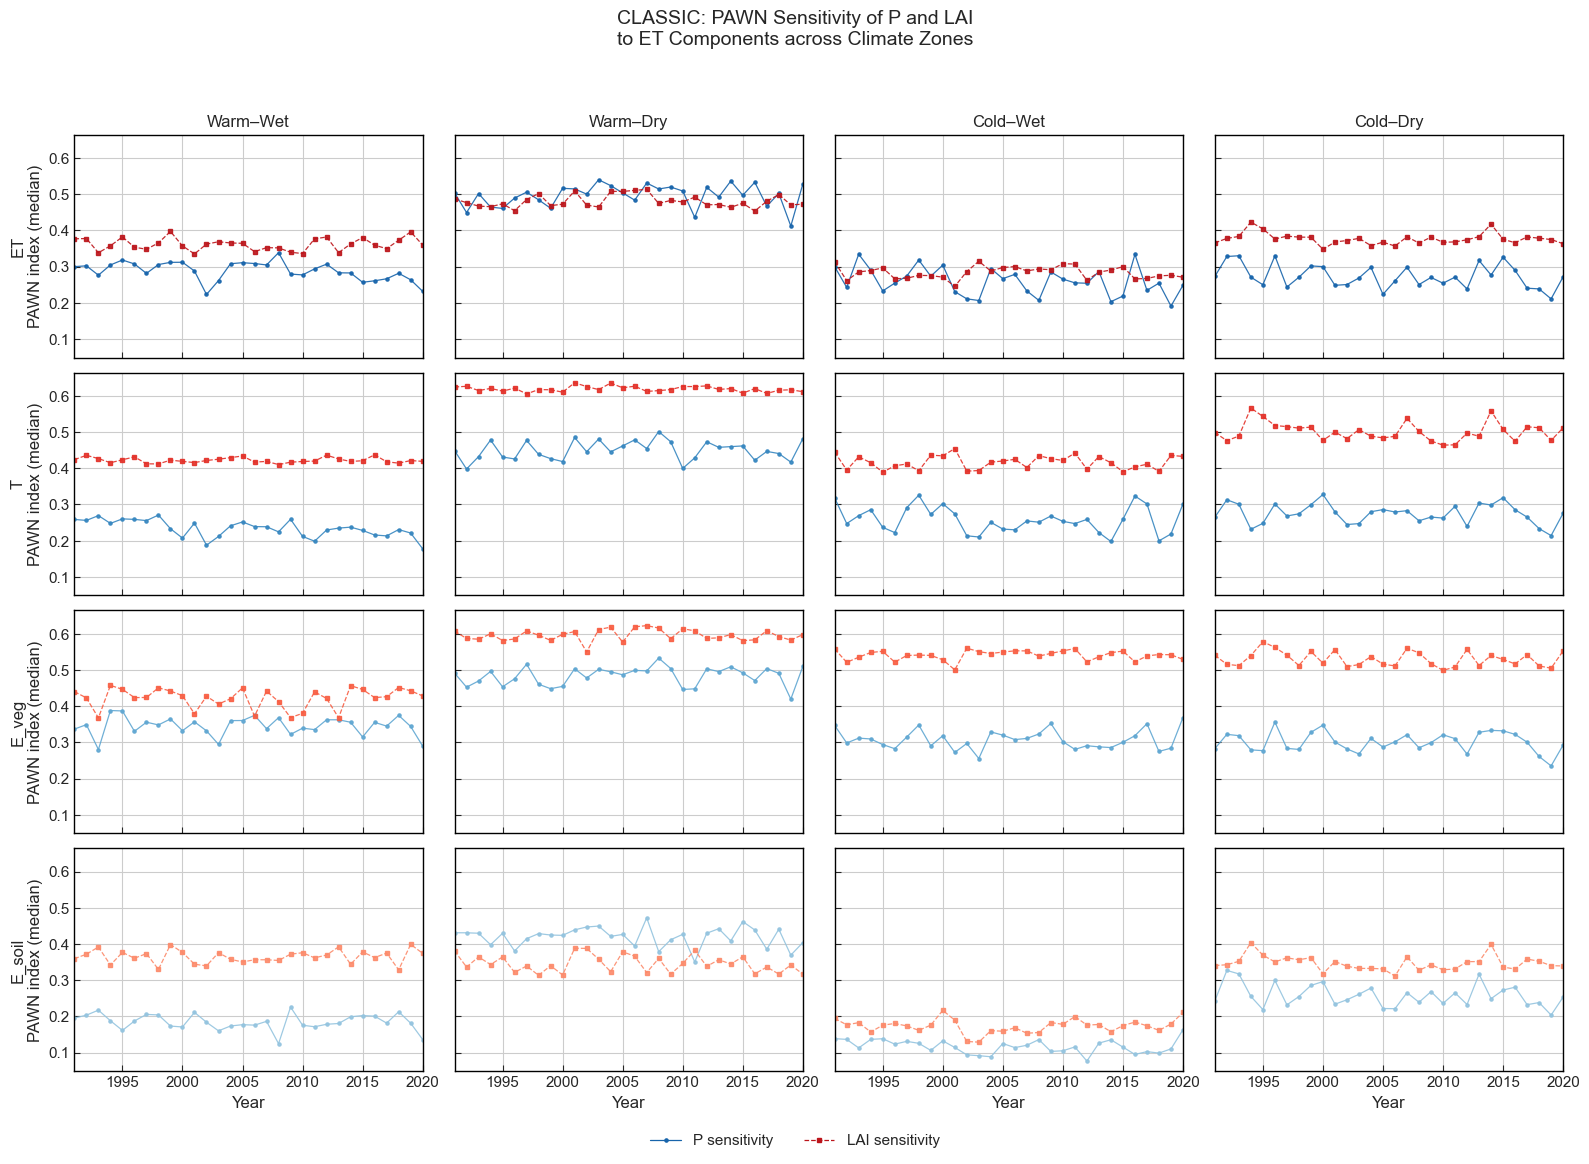

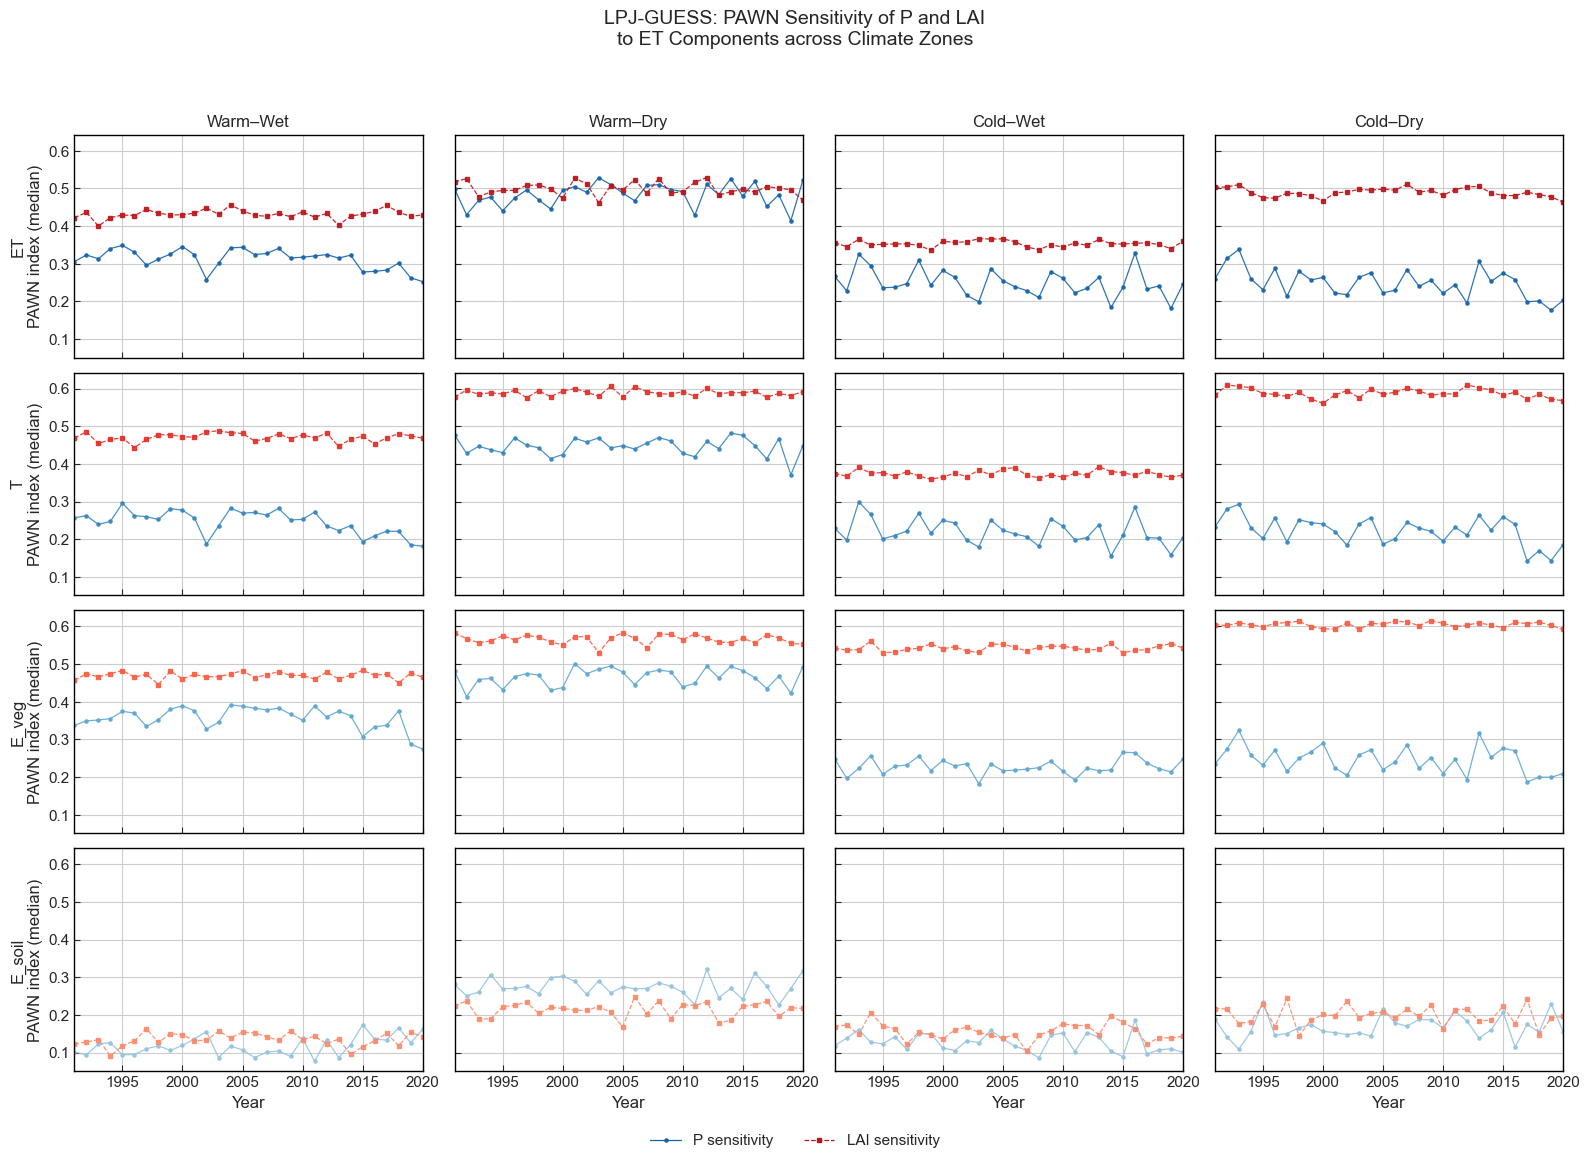

In [80]:
# -*- coding: utf-8 -*-
"""
两张 4×4 图：
  - 第一张：CLASSIC
  - 第二张：LPJ-GUESS

每张图：
  - 列：四个气候区 HW / HD / CW / CD
  - 行：四个输出变量 ET / T / E_veg / E_soil
  - 每个子图：两条线
        P (precipitation)  → 蓝色实线 + 圆点
        LAI               → 红色虚线 + 方点
样式、颜色、尺寸与原 2×4 图保持一致。
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.lines import Line2D

# ========== 1. 读入数据 ==========
df = pd.read_csv("./output/30y_pawn/all_30y_pawn_results.csv")

# 统一类型，只保留 P 和 LAI
df["year"] = df["year"].astype(int)
df = df[df["input_var"].isin(["precipitation", "lai"])]

# ========== 2. 基本参数 ==========
models = ["CLASSIC", "LPJ-GUESS"]
zones = ["HW", "HD", "CW", "CD"]
outputs = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]
output_titles = {
    "evapotrans": "ET",
    "tran": "T",
    "evspsblveg": "E_veg",
    "evspsblsoi": "E_soil",
}
zone_titles = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}

# ========= 3. 配色方案 =========
# 与原图保持一致：4 个深浅对应 4 个输出
blues = plt.cm.Blues(np.linspace(0.4, 0.8, len(outputs)))[::-1]
reds  = plt.cm.Reds(np.linspace(0.4, 0.8, len(outputs)))[::-1]

# ========= 4. 样式设置 =========
mpl.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
plt.style.use("seaborn-v0_8-whitegrid")

xlim_min, xlim_max = df["year"].min(), df["year"].max()

# ========= 5. 封装一个画单个模型 4×4 图的函数 =========
def plot_model(model_name):
    sub_model = df[df["model"] == model_name]

    fig, axes = plt.subplots(4, 4, figsize=(16, 12),
                             sharex=True, sharey=True)
    plt.subplots_adjust(wspace=0.25, hspace=0.25)

    for i, out in enumerate(outputs):      # 行：不同输出变量
        for j, zone in enumerate(zones):   # 列：不同气候区
            ax = axes[i, j]
            sub = sub_model[sub_model["climate_zone"] == zone]

            # --- P 蓝色（实线） ---
            sP = sub[(sub["input_var"] == "precipitation") &
                     (sub["output_var"] == out)].sort_values("year")
            if not sP.empty:
                ax.plot(
                    sP["year"], sP["pawn_median"],
                    color=blues[i], lw=0.9,
                    marker="o", ms=2.3,
                    alpha=0.9, linestyle="-"
                )

            # --- LAI 红色（虚线） ---
            sL = sub[(sub["input_var"] == "lai") &
                     (sub["output_var"] == out)].sort_values("year")
            if not sL.empty:
                ax.plot(
                    sL["year"], sL["pawn_median"],
                    color=reds[i], lw=0.9,
                    marker="s", ms=2.3,
                    alpha=0.9, linestyle="--"
                )

            # 坐标轴样式
            ax.set_xlim(xlim_min, xlim_max)
            ax.tick_params(direction="in", length=4, width=0.8)
            for spine in ax.spines.values():
                spine.set_color("black")
                spine.set_linewidth(1.0)
                spine.set_visible(True)

            # 只在最左列写 y 轴标题：对应输出变量
            if j == 0:
                ax.set_ylabel(f"{output_titles[out]}\nPAWN index (median)")

            # 只在最后一行写 x 轴标签
            if i == len(outputs) - 1:
                ax.set_xlabel("Year")

            # 第一行写分区标题
            if i == 0:
                ax.set_title(zone_titles.get(zone, zone))

    # ===== 图例：P vs LAI =====
    handle_P = Line2D([], [], color=blues[0], lw=0.9,
                      marker="o", ms=2.3, linestyle="-")
    handle_L = Line2D([], [], color=reds[0], lw=0.9,
                      marker="s", ms=2.3, linestyle="--")

    fig.legend(
        [handle_P, handle_L],
        ["P sensitivity", "LAI sensitivity"],
        loc="lower center", ncol=2, frameon=False,
        fontsize=11, bbox_to_anchor=(0.5, 0.02)
    )

    # ===== 总标题 =====
    fig.suptitle(
        f"{model_name}: PAWN Sensitivity of P and LAI\n"
        "to ET Components across Climate Zones",
        fontsize=14, y=0.98
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

# ========= 6. 分别画 CLASSIC 和 LPJ-GUESS 两张 4×4 图 =========
for m in models:
    plot_model(m)

In [83]:
# -*- coding: utf-8 -*-
"""
根据 PAWN 对 ET 的敏感度，做 dominant control 分类：
  S_LAI→ET vs S_P→ET
  - 2 类：LAI-dominated / P-dominated
  - 3 类：LAI-dominated / P-dominated / co-dominated
"""

import numpy as np
import pandas as pd

# ===== 1. 读入 PAWN 结果 =====
pawn_path = "./output/30y_pawn/all_30y_pawn_results.csv"
df = pd.read_csv(pawn_path)

df["year"] = df["year"].astype(int)

# 只用 ET 的 PAWN，并且只看 P 和 LAI 作为输入
df_et = df[
    (df["output_var"] == "evapotrans") &
    (df["input_var"].isin(["precipitation", "lai"]))
].copy()

# ===== 2. 设定“单元”的分组方式 =====
# 目前用气候分区；如果以后有格点级 PAWN（带 lat, lon），
# 可以把下面改成 group_cols = ["model", "lat", "lon"] 或其它。
group_cols = ["model", "climate_zone"]

# ===== 3. 对每个单元做 30 年平均的 S_P→ET 和 S_LAI→ET =====
summary = (
    df_et
    .groupby(group_cols + ["input_var"])["pawn_median"]
    .mean()
    .reset_index()
)

# 变成宽表：每个单元一行，两列分别 S_P_ET, S_LAI_ET
pivot = (
    summary
    .pivot(index=group_cols, columns="input_var", values="pawn_median")
    .rename(columns={
        "precipitation": "S_P_ET",
        "lai": "S_LAI_ET"
    })
    .reset_index()
)

# ===== 4. 计算差值：S_LAI→ET - S_P→ET =====
pivot["diff_LAI_minus_P"] = pivot["S_LAI_ET"] - pivot["S_P_ET"]

# ===== 5. 2 类分类：LAI-dominated / P-dominated =====
pivot["dom_2class"] = np.where(
    pivot["diff_LAI_minus_P"] > 0,
    "LAI-dominated",
    "P-dominated"
)

# ===== 6. 3 类分类：加容差 δ，做 co-dominated =====
# δ 可以自己调，比如 0.01 或 0.02，看 PAWN 的量级
delta = 0.02

pivot["dom_3class"] = np.select(
    [
        pivot["diff_LAI_minus_P"] >  delta,   # 明显偏 LAI
        pivot["diff_LAI_minus_P"] < -delta,   # 明显偏 P
    ],
    [
        "LAI-dominated",
        "P-dominated",
    ],
    default="co-dominated"                    # 差值很小 → 共同控制
)

# ===== 7. 保存结果，后续可用来画 map 或柱状图 =====
out_path = "./output/dominant_ET_control_by_zone.csv"
pivot.to_csv(out_path, index=False)

print("已生成 dominant 控制分类表：", out_path)
print(pivot.head())

已生成 dominant 控制分类表： ./output/30y_pawn/dominant_ET_control_by_zone.csv
input_var      model climate_zone  S_LAI_ET    S_P_ET  diff_LAI_minus_P  \
0            CLASSIC           CD  0.376749  0.273280          0.103469   
1            CLASSIC           CW  0.283721  0.259346          0.024374   
2            CLASSIC           HD  0.480634  0.496603         -0.015969   
3            CLASSIC           HW  0.361518  0.288127          0.073391   
4          LPJ-GUESS           CD  0.489519  0.248217          0.241301   

input_var     dom_2class     dom_3class  
0          LAI-dominated  LAI-dominated  
1          LAI-dominated  LAI-dominated  
2            P-dominated   co-dominated  
3          LAI-dominated  LAI-dominated  
4          LAI-dominated  LAI-dominated  


In [204]:
# -*- coding: utf-8 -*-
"""
Coupled elasticity pattern:
对每个单元（这里是 model × climate_zone），计算
corr(S_P→ET, S_LAI→ET) 随时间的相关系数。
"""

import pandas as pd
import numpy as np

# ========= 1. 读入 PAWN 结果 =========
pawn_path = "./output/30y_pawn/all_30y_pawn_results.csv"
df = pd.read_csv(pawn_path)

df["year"] = df["year"].astype(int)

# 只用 ET 的 PAWN，且只看 P 和 LAI 两个输入
df_et = df[
    (df["output_var"] == "evapotrans") &
    (df["input_var"].isin(["precipitation", "lai"]))
].copy()

# ========= 2. 设定“单元”的分组方式 =========
# 现在按 model × climate_zone；如果以后要到格点级，
# 把 group_cols 改成 ["model", "lat", "lon"] 即可。
group_cols = ["model", "climate_zone"]

# ========= 3. 整理成宽表：每个单元一个时间序列 =========
# 行：year；列：input_var（precipitation / lai）
# 为了方便，先按 group 循环。
results = []

for keys, sub in df_et.groupby(group_cols):
    # keys 是一个元组，例如 ("CLASSIC", "HW")
    # 把时间序列 pivot 成 year × input_var
    ts = (
        sub.pivot_table(
            index="year",
            columns="input_var",
            values="pawn_median"
        )
        .dropna()  # 把缺少任意一方的年份丢掉
    )

    # 要有至少 2 个年份才能算相关
    if ts.shape[0] < 2:
        corr_val = np.nan
    else:
        # pandas 的 corr 默认是 Pearson 相关
        corr_val = ts["precipitation"].corr(ts["lai"])

    result_row = dict(zip(group_cols, keys))
    result_row["corr_SP_ET__SLAI_ET"] = corr_val
    result_row["n_years_used"] = ts.shape[0]
    results.append(result_row)

corr_df = pd.DataFrame(results)

# ========= 4. 根据相关系数简单分类（可选） =========
# 正相关：协同增强；负相关：相互抵消；接近 0：弱耦合
eps = 0.1  # 绝对值小于 eps 视为“weak / neutral”，可按需要调整

corr_df["coupling_type"] = np.select(
    [
        corr_df["corr_SP_ET__SLAI_ET"] >  eps,
        corr_df["corr_SP_ET__SLAI_ET"] < -eps,
    ],
    [
        "positive_coupling",   # P 与 LAI 对 ET 的敏感性同向变化
        "negative_coupling",   # P 增强时 LAI 敏感度减弱，反之亦然
    ],
    default="weak_or_neutral"
)

# ========= 5. 导出结果 =========
out_path = "./output/30y_pawn/coupled_elasticity_corr_by_zone.csv"
corr_df.to_csv(out_path, index=False)

print("已生成灵敏度-环境协同分析结果：", out_path)
print(corr_df)

已生成灵敏度-环境协同分析结果： ./output/coupled_elasticity_corr_by_zone.csv
       model climate_zone  corr_SP_ET__SLAI_ET  n_years_used  \
0    CLASSIC           CD             0.060289            30   
1    CLASSIC           CW            -0.070078            30   
2    CLASSIC           HD            -0.037152            30   
3    CLASSIC           HW             0.123471            30   
4  LPJ-GUESS           CD             0.293437            30   
5  LPJ-GUESS           CW             0.249388            30   
6  LPJ-GUESS           HD            -0.212013            30   
7  LPJ-GUESS           HW            -0.109232            30   

       coupling_type  
0    weak_or_neutral  
1    weak_or_neutral  
2    weak_or_neutral  
3  positive_coupling  
4  positive_coupling  
5  positive_coupling  
6  negative_coupling  
7  negative_coupling  


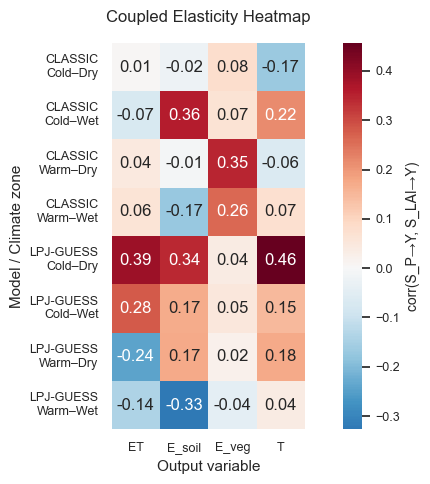

In [102]:
# -*- coding: utf-8 -*-
"""
绘制 P 与 LAI 对各通量敏感性耦合的热力图
横轴：输出变量（ET, T, E_veg, E_soil）
纵轴：模型 × 气候区（Warm–Wet, Warm–Dry, Cold–Wet, Cold–Dry）
颜色：corr(S_P→Y, S_LAI→Y)
去掉边框，每个单元格长宽相同
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ========= 1. 读取 PAWN 结果 =========
df = pd.read_csv("./output/30y_pawn/all_30y_pawn_results.csv")
df["year"] = df["year"].astype(int)
df = df[df["input_var"].isin(["precipitation", "lai"])]

outputs = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]
out_label_map = {
    "evapotrans": "ET",
    "tran": "T",
    "evspsblveg": "E_veg",
    "evspsblsoi": "E_soil",
}

# ========= 2. 计算 corr(S_P→Y, S_LAI→Y) =========
group_cols = ["model", "climate_zone", "output_var"]
results = []

for keys, sub in df.groupby(group_cols):
    model, zone, outvar = keys
    ts = (
        sub.pivot_table(index="year", columns="input_var", values="pawn_median")
        .dropna()
    )
    corr_val = ts["precipitation"].corr(ts["lai"]) if ts.shape[0] > 1 else np.nan
    results.append({
        "model": model,
        "climate_zone": zone,
        "output_label": out_label_map[outvar],
        "corr_SP_Y__SLAI_Y": corr_val,
    })

corr_df = pd.DataFrame(results)

# ========= 3. 构建热力图矩阵 =========
pivot = corr_df.pivot_table(
    index=["model", "climate_zone"],
    columns="output_label",
    values="corr_SP_Y__SLAI_Y"
)

# --- 修改气候区缩写为完整形式 ---
zone_fullname = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry"
}
pivot.index = [f"{m}\n{zone_fullname.get(z, z)}" for (m, z) in pivot.index]

# ========= 4. 绘制热力图 =========
plt.figure(figsize=(8, 5))
ax = sns.heatmap(
    pivot,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    square=True,                      # 每个矩形长宽一致
    cbar_kws={"label": "corr(S_P→Y, S_LAI→Y)"},
    linewidths=0,                     # 去掉单元格边框
   
)

# ========= 5. 细节美化 =========
ax.set_xlabel("Output variable", fontsize=11)
ax.set_ylabel("Model / Climate zone", fontsize=11)
ax.set_title("Coupled Elasticity Heatmap", fontsize=12, pad=15)
# 修改颜色条字体大小
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)   # ✅ 改 tick 字体大小
cbar.set_label("corr(S_P→Y, S_LAI→Y)", fontsize=10)  # ✅ 改标签字体大小

for label in ax.get_yticklabels():
    text = label.get_text()
    label.set_fontsize(9)   # LPJ 小一点
for label in ax.get_xticklabels():
    text = label.get_text()
    label.set_fontsize(9)   # LPJ 小一点
# 去掉四周外框
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

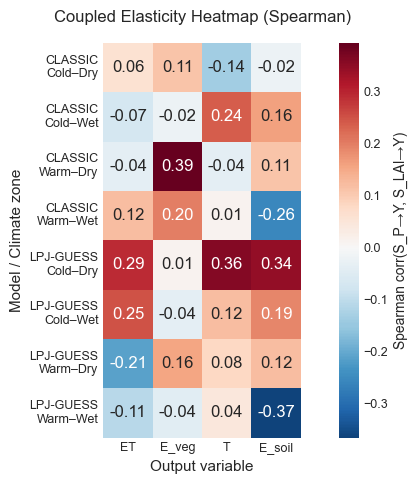

In [206]:
# -*- coding: utf-8 -*-
"""
绘制 P 与 LAI 对各通量敏感性耦合的热力图（Spearman 相关）

横轴：输出变量（ET, T, E_veg, E_soil）
纵轴：模型 × 气候区（Warm–Wet, Warm–Dry, Cold–Wet, Cold–Dry）
颜色：Spearman corr(S_P→Y(t), S_LAI→Y(t))
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr   # ✅ 显式使用 Spearman

# ========= 1. 读取 PAWN 结果 =========
df = pd.read_csv("./output/30y_pawn/all_30y_pawn_results.csv")
df["year"] = df["year"].astype(int)

# 只保留 P 和 LAI 的敏感性
df = df[df["input_var"].isin(["precipitation", "lai"])]

# 输出变量及标签映射
outputs = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]
out_label_map = {
    "evapotrans": "ET",
    "tran": "T",
    "evspsblveg": "E_veg",
    "evspsblsoi": "E_soil",
}

# ========= 2. 计算 Spearman corr(S_P→Y, S_LAI→Y) =========
group_cols = ["model", "climate_zone", "output_var"]
results = []

for keys, sub in df.groupby(group_cols):
    model, zone, outvar = keys

    # year × input_var 的时间序列表
    ts = (
        sub.pivot_table(index="year", columns="input_var", values="pawn_median")
        .dropna()
    )

    if ts.shape[0] > 1:
        # ✅ 使用 Spearman 相关
        r, pval = spearmanr(ts["precipitation"], ts["lai"])
        corr_val = r
    else:
        corr_val = np.nan

    results.append({
        "model": model,
        "climate_zone": zone,
        "output_label": out_label_map[outvar],
        "corr_SP_Y__SLAI_Y": corr_val,
    })

corr_df = pd.DataFrame(results)

# ========= 3. 构建热力图矩阵 =========
pivot = corr_df.pivot_table(
    index=["model", "climate_zone"],
    columns="output_label",
    values="corr_SP_Y__SLAI_Y"
)

# 气候区全称
zone_fullname = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry"
}
# 行索引改成 “MODEL\nzone”的形式
pivot.index = [f"{m}\n{zone_fullname.get(z, z)}" for (m, z) in pivot.index]

# 按列顺序排序（可选）
pivot = pivot[["ET", "E_veg", "T", "E_soil"]]  # 如果你想固定顺序，可以调整

# ========= 4. 绘制热力图 =========
plt.figure(figsize=(8, 5))
ax = sns.heatmap(
    pivot,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    square=True,                      # 每个矩形长宽一致
    cbar_kws={"label": "Spearman corr(S_P→Y, S_LAI→Y)"},
    linewidths=0                      # 去掉单元格边框
)

# ========= 5. 细节美化 =========
ax.set_xlabel("Output variable", fontsize=11)
ax.set_ylabel("Model / Climate zone", fontsize=11)
ax.set_title("Coupled Elasticity Heatmap (Spearman)", fontsize=12, pad=15)

# 颜色条样式
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Spearman corr(S_P→Y, S_LAI→Y)", fontsize=10)

# 坐标轴标签字号
for label in ax.get_yticklabels():
    label.set_fontsize(9)
for label in ax.get_xticklabels():
    label.set_fontsize(9)

# 去掉四周外框
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

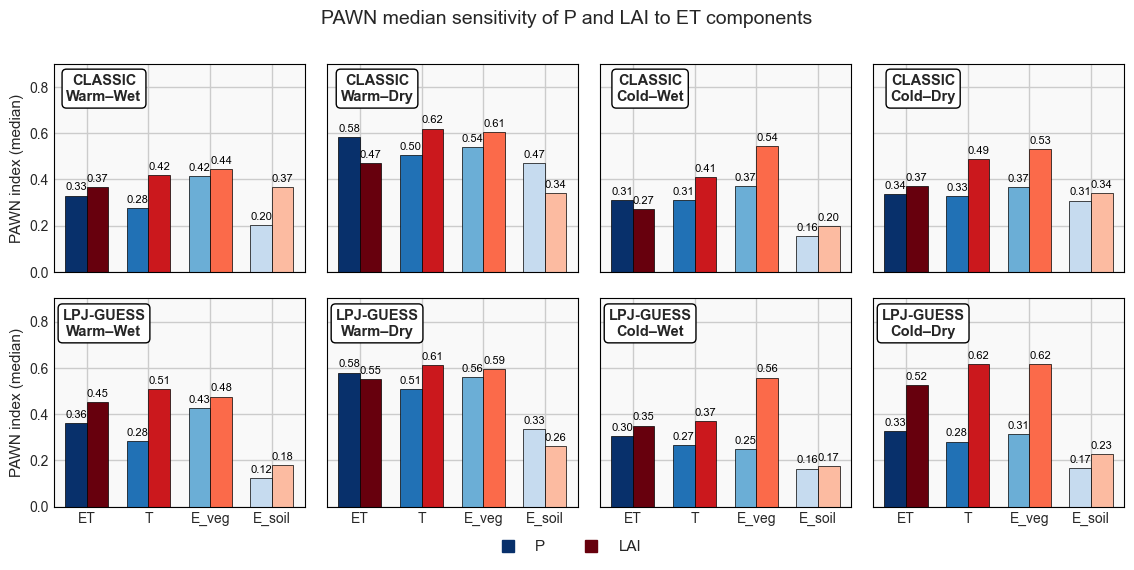

In [159]:
# -*- coding: utf-8 -*-
"""
2×4 美化版柱状图
- 每行代表一个模型 (CLASSIC / LPJ-GUESS)
- 每列代表一个气候区 (HW / HD / CW / CD)
- 内嵌子标题标签 + 自定义配色
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ========= 0. 文件路径 =========
classic_csv = "./output/30mean/classic_gsa_by_zone.csv"
lpj_csv     = "./output/30mean/lpj_gsa_by_zone.csv"

classic_df = pd.read_csv(classic_csv)
lpj_df     = pd.read_csv(lpj_csv)

cols_keep = ["Output", "Input", "PAWN_median", "Zone"]
classic_df = classic_df[cols_keep]
lpj_df     = lpj_df[cols_keep]

# ========= 1. 设置 =========
zones = ["HW", "HD", "CW", "CD"]
zone_titles = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}
x_labels = ["ET", "T", "E_veg", "E_soil"]
label_order = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

# P：蓝色系
blues = ["#08306b", "#2171b5", "#6baed6", "#c6dbef"]
# LAI：红色系
reds = ["#67000d", "#cb181d", "#fb6a4a", "#fcbba1"]

mpl.rcParams.update({
    "axes.linewidth": 1.0,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 2. 创建画布 =========
fig, axes = plt.subplots(2, 4, figsize=(11.5, 6), sharey=True)
plt.subplots_adjust(wspace=0.25, hspace=0.35)

bar_width = 0.35
x = np.arange(len(label_order))

# ========= 3. 绘图 =========
for row, (df, model_name) in enumerate([(classic_df, "CLASSIC"), (lpj_df, "LPJ-GUESS")]):
    for col, zone in enumerate(zones):
        ax = axes[row, col]
        sub = df[df["Zone"] == zone]
        pivot = sub.pivot(index="Output", columns="Input", values="PAWN_median")

        # 背景
        ax.set_facecolor("#f9f9f9")

        for k, out in enumerate(label_order):
            xc = x[k]
            p_val = pivot.loc[out, "precipitation"] if ("precipitation" in pivot.columns and out in pivot.index) else np.nan
            l_val = pivot.loc[out, "lai"] if ("lai" in pivot.columns and out in pivot.index) else np.nan

            if not np.isnan(p_val):
                bar_p = ax.bar(
                    xc - bar_width/2,
                    p_val,
                    width=bar_width,
                    color=blues[k],
                    edgecolor="black",
                    linewidth=0.5,
                )
                ax.text(
                    xc - bar_width/2, p_val + 0.015,
                    f"{p_val:.2f}",
                    ha="center", va="bottom", fontsize=8, color="black"
                )
            if not np.isnan(l_val):
                bar_l = ax.bar(
                    xc + bar_width/2,
                    l_val,
                    width=bar_width,
                    color=reds[k],
                    edgecolor="black",
                    linewidth=0.5,
                )
                ax.text(
                    xc + bar_width/2, l_val + 0.015,
                    f"{l_val:.2f}",
                    ha="center", va="bottom", fontsize=8, color="black"
                )

        # 坐标样式
        ax.set_xticks(x)
        ax.set_ylim(0, 0.9)
        ax.tick_params(axis="both", direction="in", length=4, width=0.8)

        # ✅ 第一行去掉 x 轴标签
        if row == 0:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels(x_labels)

        # y轴
        if col == 0:
            ax.set_ylabel("PAWN index (median)")
        else:
            ax.set_ylabel("")

        # ==== 内嵌标题 ====
        ax.text(
            0.2, 0.88, f"{model_name}\n{zone_titles[zone]}",
            transform=ax.transAxes,
            fontsize=10.5, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
            ha="center", va="center"
        )

        # 边框
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(0.8)

# ========= 4. 图例 =========
legend_handles = [
    Line2D([], [], color=blues[0], marker="s", linestyle="None", markersize=8, label="P"),
    Line2D([], [], color=reds[0], marker="s", linestyle="None", markersize=8, label="LAI"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.02),
)

# ========= 5. 总标题 =========
fig.suptitle(
    "PAWN median sensitivity of P and LAI to ET components",
    fontsize=14, y=0.95
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

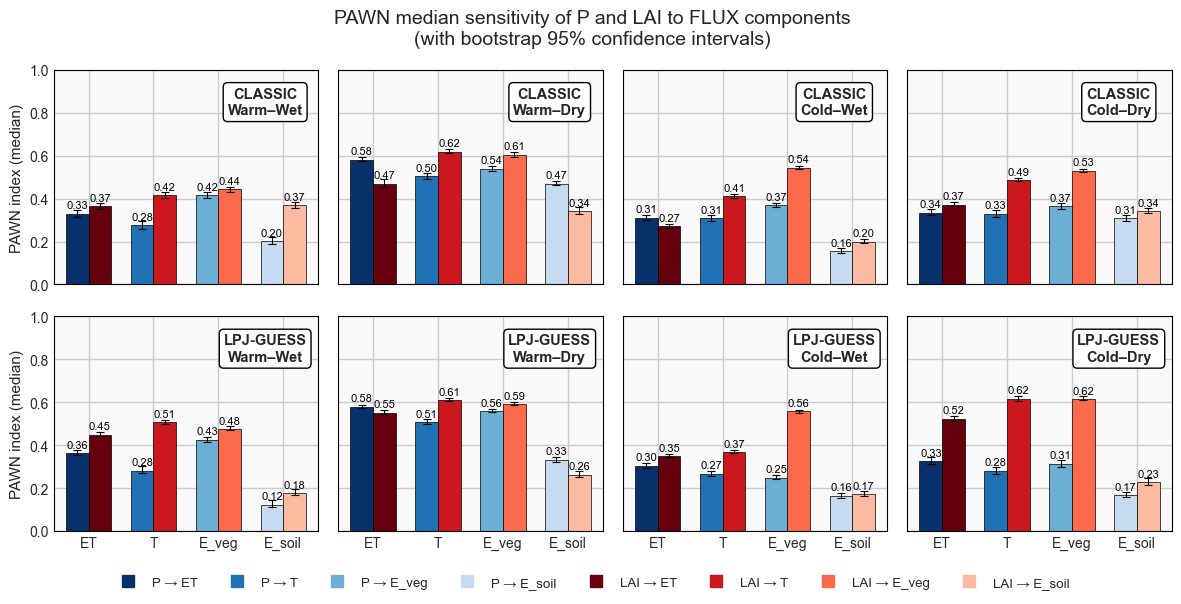

In [176]:
# -*- coding: utf-8 -*-
"""
2×4 美化版柱状图 + 置信区间
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ========= 0. 文件路径 =========
classic_csv      = "./output/30mean/classic_gsa_by_zone.csv"
lpj_csv          = "./output/30mean/lpj_gsa_by_zone.csv"
classic_boot_csv = "./output/30mean/classic_bootstrap_results.csv"
lpj_boot_csv     = "./output/30mean/lpj_bootstrap_results.csv"

# 主数据（柱子高度）
classic_df = pd.read_csv(classic_csv)
lpj_df     = pd.read_csv(lpj_csv)
cols_keep = ["Output", "Input", "PAWN_median", "Zone"]
classic_df = classic_df[cols_keep]
lpj_df     = lpj_df[cols_keep]

# bootstrap 结果（置信区间）
classic_boot = pd.read_csv(classic_boot_csv)
lpj_boot     = pd.read_csv(lpj_boot_csv)
boot_keep = ["Zone", "Output", "Input", "pawn_ci_lower", "pawn_ci_upper"]
classic_boot = classic_boot[boot_keep]
lpj_boot     = lpj_boot[boot_keep]

# ========= 1. 设置 =========
zones = ["HW", "HD", "CW", "CD"]
zone_titles = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}
x_labels = ["ET", "T", "E_veg", "E_soil"]
label_order = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

# P：蓝色系
blues = ["#08306b", "#2171b5", "#6baed6", "#c6dbef"]
# LAI：红色系
reds = ["#67000d", "#cb181d", "#fb6a4a", "#fcbba1"]

mpl.rcParams.update({
    "axes.linewidth": 1.0,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 2. 创建画布 =========
fig, axes = plt.subplots(2, 4, figsize=(12, 6.5), sharey=True)
plt.subplots_adjust(wspace=0.25, hspace=0.35)

bar_width = 0.35
x = np.arange(len(label_order))

# ========= 3. 绘图 =========
for row, (df, boot_df, model_name) in enumerate(
        [(classic_df, classic_boot, "CLASSIC"),
         (lpj_df,     lpj_boot,     "LPJ-GUESS")]):

    for col, zone in enumerate(zones):
        ax = axes[row, col]
        sub = df[df["Zone"] == zone]
        pivot = sub.pivot(index="Output", columns="Input", values="PAWN_median")

        boot_sub = boot_df[boot_df["Zone"] == zone]

        # 背景
        ax.set_facecolor("#f9f9f9")

        for k, out in enumerate(label_order):
            xc = x[k]

            # ----- P -----
            if ("precipitation" in pivot.columns) and (out in pivot.index):
                p_val = pivot.loc[out, "precipitation"]
                bar_p = ax.bar(
                    xc - bar_width/2,
                    p_val,
                    width=bar_width,
                    color=blues[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                ax.text(
                    xc - bar_width/2, p_val + 0.015,
                    f"{p_val:.2f}",
                    ha="center", va="bottom", fontsize=8, color="black",
                    zorder=3
                )
                # 找到对应的 CI
                ci_p = boot_sub[(boot_sub["Output"] == out) &
                                (boot_sub["Input"] == "precipitation")]
                if not ci_p.empty:
                    lower = ci_p["pawn_ci_lower"].iloc[0]
                    upper = ci_p["pawn_ci_upper"].iloc[0]
                    yerr = [[p_val - lower], [upper - p_val]]
                    ax.errorbar(
                        xc - bar_width/2, p_val,
                        yerr=yerr,
                        fmt="none",
                        ecolor="black",
                        elinewidth=0.8,
                        capsize=3,
                        capthick=0.8,
                        zorder=4
                    )

            # ----- LAI -----
            if ("lai" in pivot.columns) and (out in pivot.index):
                l_val = pivot.loc[out, "lai"]
                bar_l = ax.bar(
                    xc + bar_width/2,
                    l_val,
                    width=bar_width,
                    color=reds[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                ax.text(
                    xc + bar_width/2, l_val + 0.015,
                    f"{l_val:.2f}",
                    ha="center", va="bottom", fontsize=8, color="black",
                    zorder=3
                )
                ci_l = boot_sub[(boot_sub["Output"] == out) &
                                (boot_sub["Input"] == "lai")]
                if not ci_l.empty:
                    lower = ci_l["pawn_ci_lower"].iloc[0]
                    upper = ci_l["pawn_ci_upper"].iloc[0]
                    yerr = [[l_val - lower], [upper - l_val]]
                    ax.errorbar(
                        xc + bar_width/2, l_val,
                        yerr=yerr,
                        fmt="none",
                        ecolor="black",
                        elinewidth=0.8,
                        capsize=3,
                        capthick=0.8,
                        zorder=4
                    )

        # 坐标样式
        ax.set_xticks(x)
        ax.set_ylim(0, 1.0)
        ax.tick_params(axis="both", direction="in", length=4, width=0.8)

        # 第一行去掉 x 轴标签，第二行保留
        if row == 0:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels(x_labels)

        # y 轴
        if col == 0:
            ax.set_ylabel("PAWN index (median)")
        else:
            ax.set_ylabel("")

        # 内嵌标题
        ax.text(
            0.8, 0.85, f"{model_name}\n{zone_titles[zone]}",
            transform=ax.transAxes,
            fontsize=10.5, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
            ha="center", va="center",
            zorder=5
        )

        # 边框
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(0.8)

# ========= 4. 图例（蓝色第一行，红色第二行） =========
from matplotlib.lines import Line2D

label_order = ["ET", "T", "E_veg", "E_soil"]

legend_handles = []
# P 系列（蓝色）
for lbl, color in zip(label_order, blues):
    legend_handles.append(Line2D([], [], color=color, marker="s", linestyle="None",
                                 markersize=8, label=f"P → {lbl}"))
# LAI 系列（红色）
for lbl, color in zip(label_order, reds):
    legend_handles.append(Line2D([], [], color=color, marker="s", linestyle="None",
                                 markersize=8, label=f"LAI → {lbl}"))

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=8,               # ✅ 单行显示所有图例项
    frameon=False,
    fontsize=9.5,         # 字体略小，避免拥挤
    bbox_to_anchor=(0.5, 0.01),  # 向下微调
)
# 调整两行显示顺序：P 在上、LAI 在下
# Matplotlib 自动会按 handles 顺序分行
# 因此上面 p_handles + lai_handles 顺序已保证第一行是 P、第二行是 LAI

# ========= 5. 总标题 =========
fig.suptitle(
    "PAWN median sensitivity of P and LAI to FLUX components\n(with bootstrap 95% confidence intervals)",
    fontsize=14, y=0.92
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

In [178]:
import pandas as pd

# 读取你的CSV文件
df = pd.read_csv("./output/30mean/classic_bootstrap_results.csv")

# 计算置信区间宽度
df["ci_width"] = df["pawn_ci_upper"] - df["pawn_ci_lower"]

# 定义判断阈值
width_threshold = 0.05  # 或 0.1，根据你的样本量和研究标准调整

# 判断稳定性
df["pawn_stable"] = (df["ci_width"] < width_threshold)

# 进一步定义“稳健且显著”
df["pawn_reliable"] = df["pawn_stable"] & df["pawn_significant"]

# 输出结果
print(df[["Model","Zone","Output","Input","pawn_boot_mean","pawn_ci_lower","pawn_ci_upper","ci_width","pawn_significant","pawn_stable","pawn_reliable"]])


      Model Zone      Output          Input  pawn_boot_mean  pawn_ci_lower  \
0   CLASSIC   HW  evapotrans  precipitation        0.331801       0.316331   
1   CLASSIC   HW  evapotrans            lai        0.368234       0.353256   
2   CLASSIC   HW        tran  precipitation        0.276637       0.259039   
3   CLASSIC   HW        tran            lai        0.418735       0.405258   
4   CLASSIC   HW  evspsblveg  precipitation        0.418141       0.405312   
5   CLASSIC   HW  evspsblveg            lai        0.443966       0.431877   
6   CLASSIC   HW  evspsblsoi  precipitation        0.204301       0.189291   
7   CLASSIC   HW  evspsblsoi            lai        0.370852       0.356858   
8   CLASSIC   HD  evapotrans  precipitation        0.583352       0.574727   
9   CLASSIC   HD  evapotrans            lai        0.470900       0.452140   
10  CLASSIC   HD        tran  precipitation        0.505737       0.493604   
11  CLASSIC   HD        tran            lai        0.622114     

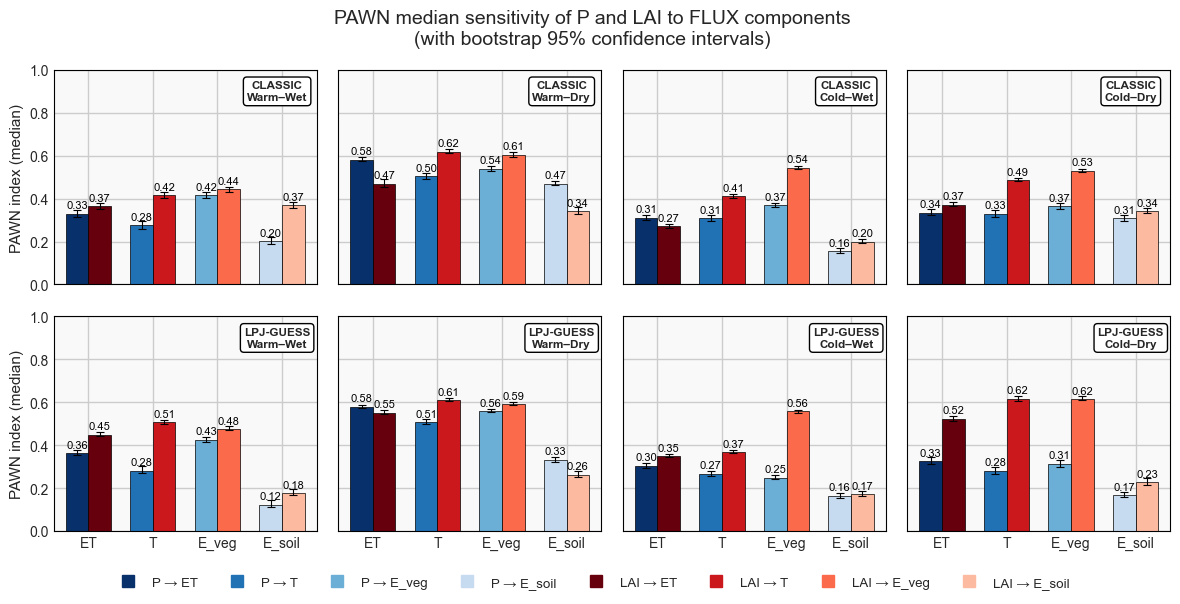

In [197]:
# -*- coding: utf-8 -*-
"""
2×4 美化版柱状图 + 置信区间
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ========= 0. 文件路径 =========
classic_csv      = "./output/30mean/classic_gsa_by_zone.csv"
lpj_csv          = "./output/30mean/lpj_gsa_by_zone.csv"
classic_boot_csv = "./output/30mean/classic_bootstrap_results.csv"
lpj_boot_csv     = "./output/30mean/lpj_bootstrap_results.csv"

# 主数据（柱子高度）
classic_df = pd.read_csv(classic_csv)
lpj_df     = pd.read_csv(lpj_csv)
cols_keep = ["Output", "Input", "PAWN_median", "Zone"]
classic_df = classic_df[cols_keep]
lpj_df     = lpj_df[cols_keep]

# bootstrap 结果（置信区间）
classic_boot = pd.read_csv(classic_boot_csv)
lpj_boot     = pd.read_csv(lpj_boot_csv)
boot_keep = ["Zone", "Output", "Input", "pawn_ci_lower", "pawn_ci_upper"]
classic_boot = classic_boot[boot_keep]
lpj_boot     = lpj_boot[boot_keep]

# ========= 1. 设置 =========
zones = ["HW", "HD", "CW", "CD"]
zone_titles = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}
x_labels = ["ET", "T", "E_veg", "E_soil"]
label_order = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

# P：蓝色系
blues = ["#08306b", "#2171b5", "#6baed6", "#c6dbef"]
# LAI：红色系
reds = ["#67000d", "#cb181d", "#fb6a4a", "#fcbba1"]

mpl.rcParams.update({
    "axes.linewidth": 1.0,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 2. 创建画布 =========
fig, axes = plt.subplots(2, 4, figsize=(12, 6.5), sharey=True)
plt.subplots_adjust(wspace=0.25, hspace=0.35)

bar_width = 0.35
x = np.arange(len(label_order))

# ========= 3. 绘图 =========
for row, (df, boot_df, model_name) in enumerate(
        [(classic_df, classic_boot, "CLASSIC"),
         (lpj_df,     lpj_boot,     "LPJ-GUESS")]):

    for col, zone in enumerate(zones):
        ax = axes[row, col]
        sub = df[df["Zone"] == zone]
        pivot = sub.pivot(index="Output", columns="Input", values="PAWN_median")

        boot_sub = boot_df[boot_df["Zone"] == zone]

        # 背景
        ax.set_facecolor("#f9f9f9")

        for k, out in enumerate(label_order):
            xc = x[k]

            # ----- P -----
            if ("precipitation" in pivot.columns) and (out in pivot.index):
                p_val = pivot.loc[out, "precipitation"]
                bar_p = ax.bar(
                    xc - bar_width/2,
                    p_val,
                    width=bar_width,
                    color=blues[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                ax.text(
                    xc - bar_width/2, p_val + 0.015,
                    f"{p_val:.2f}",
                    ha="center", va="bottom", fontsize=8, color="black",
                    zorder=3
                )
                # 找到对应的 CI
                ci_p = boot_sub[(boot_sub["Output"] == out) &
                                (boot_sub["Input"] == "precipitation")]
                if not ci_p.empty:
                    lower = ci_p["pawn_ci_lower"].iloc[0]
                    upper = ci_p["pawn_ci_upper"].iloc[0]
                    yerr = [[p_val - lower], [upper - p_val]]
                    ax.errorbar(
                        xc - bar_width/2, p_val,
                        yerr=yerr,
                        fmt="none",
                        ecolor="black",
                        elinewidth=0.8,
                        capsize=3,
                        capthick=0.8,
                        zorder=4
                    )

            # ----- LAI -----
            if ("lai" in pivot.columns) and (out in pivot.index):
                l_val = pivot.loc[out, "lai"]
                bar_l = ax.bar(
                    xc + bar_width/2,
                    l_val,
                    width=bar_width,
                    color=reds[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                ax.text(
                    xc + bar_width/2, l_val + 0.015,
                    f"{l_val:.2f}",
                    ha="center", va="bottom", fontsize=8, color="black",
                    zorder=3
                )
                ci_l = boot_sub[(boot_sub["Output"] == out) &
                                (boot_sub["Input"] == "lai")]
                if not ci_l.empty:
                    lower = ci_l["pawn_ci_lower"].iloc[0]
                    upper = ci_l["pawn_ci_upper"].iloc[0]
                    yerr = [[l_val - lower], [upper - l_val]]
                    ax.errorbar(
                        xc + bar_width/2, l_val,
                        yerr=yerr,
                        fmt="none",
                        ecolor="black",
                        elinewidth=0.8,
                        capsize=3,
                        capthick=0.8,
                        zorder=4
                    )

        # 坐标样式
        ax.set_xticks(x)
        ax.set_ylim(0, 1.0)
        ax.tick_params(axis="both", direction="in", length=4, width=0.8)

        # 第一行去掉 x 轴标签，第二行保留
        if row == 0:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels(x_labels)

        # y 轴
        if col == 0:
            ax.set_ylabel("PAWN index (median)")
        else:
            ax.set_ylabel("")

 # 内嵌标题
        ax.text(
            0.85, 0.9, f"{model_name}\n{zone_titles[zone]}",
            transform=ax.transAxes,
            fontsize=8.5, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
            ha="center", va="center",
            zorder=5
        )
        # 边框
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(0.8)

# ========= 4. 图例（蓝色第一行，红色第二行） =========
from matplotlib.lines import Line2D

label_order = ["ET", "T", "E_veg", "E_soil"]

legend_handles = []
# P 系列（蓝色）
for lbl, color in zip(label_order, blues):
    legend_handles.append(Line2D([], [], color=color, marker="s", linestyle="None",
                                 markersize=8, label=f"P → {lbl}"))
# LAI 系列（红色）
for lbl, color in zip(label_order, reds):
    legend_handles.append(Line2D([], [], color=color, marker="s", linestyle="None",
                                 markersize=8, label=f"LAI → {lbl}"))

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=8,               # ✅ 单行显示所有图例项
    frameon=False,
    fontsize=9.5,         # 字体略小，避免拥挤
    bbox_to_anchor=(0.5, 0.01),  # 向下微调
)
# 调整两行显示顺序：P 在上、LAI 在下
# Matplotlib 自动会按 handles 顺序分行
# 因此上面 p_handles + lai_handles 顺序已保证第一行是 P、第二行是 LAI

# ========= 5. 总标题 =========
fig.suptitle(
    "PAWN median sensitivity of P and LAI to FLUX components\n(with bootstrap 95% confidence intervals)",
    fontsize=14, y=0.92
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

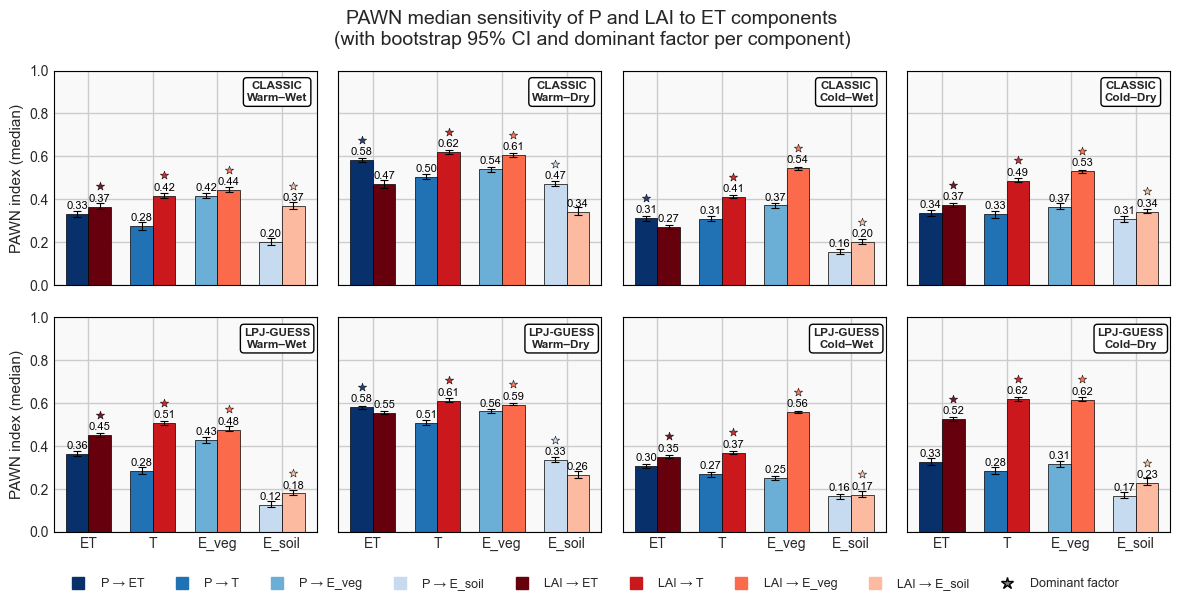

In [203]:
# -*- coding: utf-8 -*-
"""
2×4 美化版柱状图 + 置信区间 + 主控因素标记
- 行：CLASSIC / LPJ-GUESS
- 列：HW / HD / CW / CD
- 每组双柱：左 P、右 LAI（PAWN median）
- 置信区间来自 bootstrap 结果
- 主控因素来自 dominant_factors_pawn.csv，用星号标在对应柱子上方（不遮挡数字）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ========= 0. 文件路径 =========
classic_csv       = "./output/30mean/classic_gsa_by_zone.csv"
lpj_csv           = "./output/30mean/lpj_gsa_by_zone.csv"
classic_boot_csv  = "./output/30mean/classic_bootstrap_results.csv"
lpj_boot_csv      = "./output/30mean/lpj_bootstrap_results.csv"
classic_dom_csv   = "./output/30mean/classic_dominant_factors_pawn.csv"
lpj_dom_csv       = "./output/30mean/lpj_dominant_factors_pawn.csv"

# ========= 1. 读入数据 =========
# 主数据（PAWN median，用来画柱）
cols_keep = ["Output", "Input", "PAWN_median", "Zone"]
classic_df = pd.read_csv(classic_csv)[cols_keep]
lpj_df     = pd.read_csv(lpj_csv)[cols_keep]

# bootstrap 结果（置信区间）
boot_keep = ["Zone", "Output", "Input", "pawn_ci_lower", "pawn_ci_upper"]
classic_boot = pd.read_csv(classic_boot_csv)[boot_keep]
lpj_boot     = pd.read_csv(lpj_boot_csv)[boot_keep]

# 主控因素结果
# 列：Zone,Output,Dominant_Factor,Precip_Value,LAI_Value,Dominance_Ratio
classic_dom = pd.read_csv(classic_dom_csv)
lpj_dom     = pd.read_csv(lpj_dom_csv)

# ========= 2. 配置 =========
zones = ["HW", "HD", "CW", "CD"]
zone_titles = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}
x_labels    = ["ET", "T", "E_veg", "E_soil"]
label_order = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

# P：蓝色系
blues = ["#08306b", "#2171b5", "#6baed6", "#c6dbef"]
# LAI：红色系
reds  = ["#67000d", "#cb181d", "#fb6a4a", "#fcbba1"]

mpl.rcParams.update({
    "axes.linewidth": 1.0,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 3. 画布 =========
fig, axes = plt.subplots(2, 4, figsize=(12, 6.5), sharey=True)
plt.subplots_adjust(wspace=0.25, hspace=0.35)

bar_width   = 0.35
x           = np.arange(len(label_order))
y_min, y_max = 0.0, 1.0
num_offset  = 0.015   # 数字离柱顶的距离
star_offset = 0.08    # 星号再比数字高一点

# ========= 4. 绘图主循环 =========
for row, (df, boot_df, dom_df, model_name) in enumerate(
    [
        (classic_df, classic_boot, classic_dom, "CLASSIC"),
        (lpj_df,     lpj_boot,     lpj_dom,     "LPJ-GUESS"),
    ]
):
    for col, zone in enumerate(zones):
        ax = axes[row, col]

        sub      = df[df["Zone"] == zone]
        boot_sub = boot_df[boot_df["Zone"] == zone]
        dom_sub  = dom_df[dom_df["Zone"] == zone]

        # pivot: index=Output, columns=Input, values=PAWN_median
        pivot = sub.pivot(index="Output", columns="Input", values="PAWN_median")

        # 背景
        ax.set_facecolor("#f9f9f9")

        for k, out in enumerate(label_order):
            xc = x[k]

            # 这一行的主控信息（可能为空）
            dom_row = dom_sub[dom_sub["Output"] == out]
            dominant_factor = dom_row["Dominant_Factor"].iloc[0] if not dom_row.empty else None
            dom_factor_lower = dominant_factor.lower() if dominant_factor is not None else ""

            # ---- P 柱 ----
            if ("precipitation" in pivot.columns) and (out in pivot.index):
                p_val = pivot.loc[out, "precipitation"]

                # 柱
                ax.bar(
                    xc - bar_width/2,
                    p_val,
                    width=bar_width,
                    color=blues[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                # 数值
                ax.text(
                    xc - bar_width/2,
                    p_val + num_offset,
                    f"{p_val:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="black",
                    zorder=3,
                )

                # CI
                ci_p = boot_sub[
                    (boot_sub["Output"] == out) &
                    (boot_sub["Input"] == "precipitation")
                ]
                if not ci_p.empty:
                    lower = ci_p["pawn_ci_lower"].iloc[0]
                    upper = ci_p["pawn_ci_upper"].iloc[0]
                    yerr  = [[p_val - lower], [upper - p_val]]
                    ax.errorbar(
                        xc - bar_width/2,
                        p_val,
                        yerr=yerr,
                        fmt="none",
                        ecolor="black",
                        elinewidth=0.8,
                        capsize=3,
                        capthick=0.8,
                        zorder=4,
                    )
            else:
                p_val = None

            # ---- LAI 柱 ----
            if ("lai" in pivot.columns) and (out in pivot.index):
                l_val = pivot.loc[out, "lai"]
                ax.bar(
                    xc + bar_width/2,
                    l_val,
                    width=bar_width,
                    color=reds[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                ax.text(
                    xc + bar_width/2,
                    l_val + num_offset,
                    f"{l_val:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="black",
                    zorder=3,
                )

                ci_l = boot_sub[
                    (boot_sub["Output"] == out) &
                    (boot_sub["Input"] == "lai")
                ]
                if not ci_l.empty:
                    lower = ci_l["pawn_ci_lower"].iloc[0]
                    upper = ci_l["pawn_ci_upper"].iloc[0]
                    yerr  = [[l_val - lower], [upper - l_val]]
                    ax.errorbar(
                        xc + bar_width/2,
                        l_val,
                        yerr=yerr,
                        fmt="none",
                        ecolor="black",
                        elinewidth=0.8,
                        capsize=3,
                        capthick=0.8,
                        zorder=4,
                    )
            else:
                l_val = None

            # ---- 主控因素星号（放在数字上方，不遮挡） ----
            if dominant_factor is not None:
                if "precip" in dom_factor_lower and p_val is not None:
                    x_dom = xc - bar_width/2
                    y_dom = p_val
                    star_color = blues[k]   # P 主导：用蓝色星
                elif "lai" in dom_factor_lower and l_val is not None:
                    x_dom = xc + bar_width/2
                    y_dom = l_val
                    star_color = reds[k]    # LAI 主导：用红色星
                else:
                    x_dom, y_dom, star_color = None, None, None

                if x_dom is not None:
                    y_star = y_dom + num_offset + star_offset
                    # 防止超过 y_max
                    y_star = min(y_star, y_max - 0.02)
                    ax.scatter(
                        x_dom,
                        y_star,
                        marker="*",
                        s=40,
                        color=star_color,
                        edgecolors="black",
                        linewidths=0.4,
                        alpha=0.9,
                        zorder=6,
                    )

        # ==== 坐标样式 ====
        ax.set_xticks(x)
        ax.set_ylim(y_min, y_max)
        ax.tick_params(axis="both", direction="in", length=4, width=0.8)

        # 第一行不显示 x 轴刻度文字；第二行显示
        if row == 0:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels(x_labels)

        # y 轴
        if col == 0:
            ax.set_ylabel("PAWN index (median)")
        else:
            ax.set_ylabel("")

        # 内嵌标题
        ax.text(
            0.85,
            0.9,
            f"{model_name}\n{zone_titles[zone]}",
            transform=ax.transAxes,
            fontsize=8.5,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                edgecolor="black",
                boxstyle="round,pad=0.3"
            ),
            ha="center",
            va="center",
            zorder=5,
        )

        # 边框
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(0.8)

# ========= 5. 图例 =========
disp_labels = ["ET", "T", "E_veg", "E_soil"]

legend_handles = []
# P 系列（蓝）
for lbl, color in zip(disp_labels, blues):
    legend_handles.append(
        Line2D([], [], color=color, marker="s", linestyle="None",
               markersize=8, label=f"P → {lbl}")
    )
# LAI 系列（红）
for lbl, color in zip(disp_labels, reds):
    legend_handles.append(
        Line2D([], [], color=color, marker="s", linestyle="None",
               markersize=8, label=f"LAI → {lbl}")
    )
# 主控星号（用黑边星作为示例）
legend_handles.append(
    Line2D([], [], color="white", marker="*", markerfacecolor="gray",
           markeredgecolor="black", linestyle="None", markersize=9,
           label="Dominant factor")
)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=9,                 # 8 个箭头 + 1 个星
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, 0.01),
)

# ========= 6. 总标题 =========
fig.suptitle(
    "PAWN median sensitivity of P and LAI to ET components\n"
    "(with bootstrap 95% CI and dominant factor per component)",
    fontsize=14,
    y=0.92,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

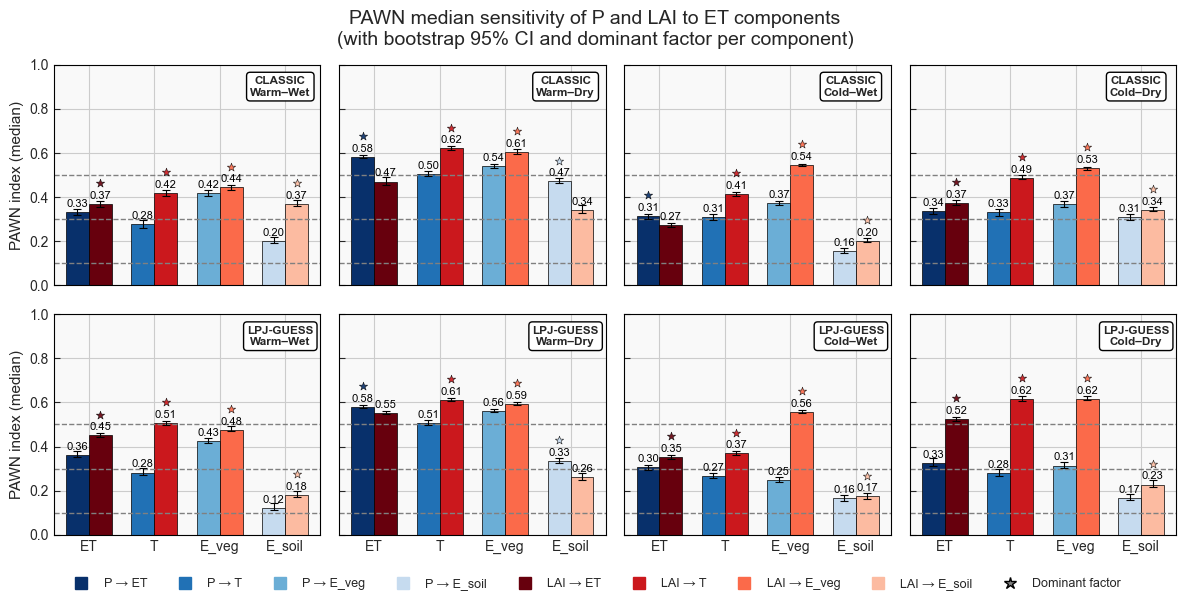

In [3]:
# -*- coding: utf-8 -*-
"""
2×4 美化版柱状图 + 置信区间 + 主控因素标记
- 行：CLASSIC / LPJ-GUESS
- 列：HW / HD / CW / CD
- 每组双柱：左 P、右 LAI（PAWN median）
- 置信区间来自 bootstrap 结果
- 主控因素来自 dominant_factors_pawn.csv，用星号标在对应柱子上方（不遮挡数字）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ========= 0. 文件路径 =========
classic_csv       = "./output/30mean/classic_gsa_by_zone.csv"
lpj_csv           = "./output/30mean/lpj_gsa_by_zone.csv"
classic_boot_csv  = "./output/30mean/classic_bootstrap_results.csv"
lpj_boot_csv      = "./output/30mean/lpj_bootstrap_results.csv"
classic_dom_csv   = "./output/30mean/classic_dominant_factors_pawn.csv"
lpj_dom_csv       = "./output/30mean/lpj_dominant_factors_pawn.csv"

# ========= 1. 读入数据 =========
# 主数据（PAWN median，用来画柱）
cols_keep = ["Output", "Input", "PAWN_median", "Zone"]
classic_df = pd.read_csv(classic_csv)[cols_keep]
lpj_df     = pd.read_csv(lpj_csv)[cols_keep]

# bootstrap 结果（置信区间）
boot_keep = ["Zone", "Output", "Input", "pawn_ci_lower", "pawn_ci_upper"]
classic_boot = pd.read_csv(classic_boot_csv)[boot_keep]
lpj_boot     = pd.read_csv(lpj_boot_csv)[boot_keep]

# 主控因素结果
# 列：Zone,Output,Dominant_Factor,Precip_Value,LAI_Value,Dominance_Ratio
classic_dom = pd.read_csv(classic_dom_csv)
lpj_dom     = pd.read_csv(lpj_dom_csv)

# ========= 2. 配置 =========
zones = ["HW", "HD", "CW", "CD"]
zone_titles = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}
x_labels    = ["ET", "T", "E_veg", "E_soil"]
label_order = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

# P：蓝色系
blues = ["#08306b", "#2171b5", "#6baed6", "#c6dbef"]
# LAI：红色系
reds  = ["#67000d", "#cb181d", "#fb6a4a", "#fcbba1"]

mpl.rcParams.update({
    "axes.linewidth": 1.0,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 3. 画布 =========
fig, axes = plt.subplots(2, 4, figsize=(12, 6.5), sharey=True)
plt.subplots_adjust(wspace=0.25, hspace=0.35)

bar_width   = 0.35
x           = np.arange(len(label_order))
y_min, y_max = 0.0, 1.0
num_offset  = 0.015   # 数字离柱顶的距离
star_offset = 0.08    # 星号再比数字高一点

# ========= 4. 绘图主循环 =========
for row, (df, boot_df, dom_df, model_name) in enumerate(
    [
        (classic_df, classic_boot, classic_dom, "CLASSIC"),
        (lpj_df,     lpj_boot,     lpj_dom,     "LPJ-GUESS"),
    ]
):
    for col, zone in enumerate(zones):
        ax = axes[row, col]

        sub      = df[df["Zone"] == zone]
        boot_sub = boot_df[boot_df["Zone"] == zone]
        dom_sub  = dom_df[dom_df["Zone"] == zone]

        # pivot: index=Output, columns=Input, values=PAWN_median
        pivot = sub.pivot(index="Output", columns="Input", values="PAWN_median")

        # 背景
        ax.set_facecolor("#f9f9f9")

        for k, out in enumerate(label_order):
            xc = x[k]

            # 这一行的主控信息（可能为空）
            dom_row = dom_sub[dom_sub["Output"] == out]
            dominant_factor = dom_row["Dominant_Factor"].iloc[0] if not dom_row.empty else None
            dom_factor_lower = dominant_factor.lower() if dominant_factor is not None else ""

            # ---- P 柱 ----
            if ("precipitation" in pivot.columns) and (out in pivot.index):
                p_val = pivot.loc[out, "precipitation"]

                # 柱
                ax.bar(
                    xc - bar_width/2,
                    p_val,
                    width=bar_width,
                    color=blues[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                # 数值
                ax.text(
                    xc - bar_width/2,
                    p_val + num_offset,
                    f"{p_val:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="black",
                    zorder=3,
                )

                # CI
                ci_p = boot_sub[
                    (boot_sub["Output"] == out) &
                    (boot_sub["Input"] == "precipitation")
                ]
                if not ci_p.empty:
                    lower = ci_p["pawn_ci_lower"].iloc[0]
                    upper = ci_p["pawn_ci_upper"].iloc[0]
                    yerr  = [[p_val - lower], [upper - p_val]]
                    ax.errorbar(
                        xc - bar_width/2,
                        p_val,
                        yerr=yerr,
                        fmt="none",
                        ecolor="black",
                        elinewidth=0.8,
                        capsize=3,
                        capthick=0.8,
                        zorder=4,
                    )
            else:
                p_val = None

            # ---- LAI 柱 ----
            if ("lai" in pivot.columns) and (out in pivot.index):
                l_val = pivot.loc[out, "lai"]
                ax.bar(
                    xc + bar_width/2,
                    l_val,
                    width=bar_width,
                    color=reds[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                ax.text(
                    xc + bar_width/2,
                    l_val + num_offset,
                    f"{l_val:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="black",
                    zorder=3,
                )

                ci_l = boot_sub[
                    (boot_sub["Output"] == out) &
                    (boot_sub["Input"] == "lai")
                ]
                if not ci_l.empty:
                    lower = ci_l["pawn_ci_lower"].iloc[0]
                    upper = ci_l["pawn_ci_upper"].iloc[0]
                    yerr  = [[l_val - lower], [upper - l_val]]
                    ax.errorbar(
                        xc + bar_width/2,
                        l_val,
                        yerr=yerr,
                        fmt="none",
                        ecolor="black",
                        elinewidth=0.8,
                        capsize=3,
                        capthick=0.8,
                        zorder=4,
                    )
            else:
                l_val = None

            # ---- 主控因素星号（放在数字上方，不遮挡） ----
            if dominant_factor is not None:
                if "precip" in dom_factor_lower and p_val is not None:
                    x_dom = xc - bar_width/2
                    y_dom = p_val
                    star_color = blues[k]   # P 主导：用蓝色星
                elif "lai" in dom_factor_lower and l_val is not None:
                    x_dom = xc + bar_width/2
                    y_dom = l_val
                    star_color = reds[k]    # LAI 主导：用红色星
                else:
                    x_dom, y_dom, star_color = None, None, None

                if x_dom is not None:
                    y_star = y_dom + num_offset + star_offset
                    # 防止超过 y_max
                    y_star = min(y_star, y_max - 0.02)
                    ax.scatter(
                        x_dom,
                        y_star,
                        marker="*",
                        s=40,
                        color=star_color,
                        edgecolors="black",
                        linewidths=0.4,
                        alpha=0.9,
                        zorder=6,
                    )

        # ==== 坐标样式 ====
        ax.set_xticks(x)
        ax.set_ylim(y_min, y_max)
        ax.tick_params(axis="both", direction="in", length=4, width=0.8)

        # 第一行不显示 x 轴刻度文字；第二行显示
        if row == 0:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels(x_labels)

        # y 轴
        if col == 0:
            ax.set_ylabel("PAWN index (median)")
        else:
            ax.set_ylabel("")

        # 内嵌标题
        ax.text(
            0.85,
            0.9,
            f"{model_name}\n{zone_titles[zone]}",
            transform=ax.transAxes,
            fontsize=8.5,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                edgecolor="black",
                boxstyle="round,pad=0.3"
            ),
            ha="center",
            va="center",
            zorder=5,
        )

        # 边框
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(0.8)

        # 在y轴上标记 0.1、0.3、0.5
        ax.axhline(y=0.1, color="gray", linestyle="--", lw=1)
        ax.axhline(y=0.3, color="gray", linestyle="--", lw=1)
        ax.axhline(y=0.5, color="gray", linestyle="--", lw=1)

# ========= 5. 图例 =========
disp_labels = ["ET", "T", "E_veg", "E_soil"]

legend_handles = []
# P 系列（蓝）
for lbl, color in zip(disp_labels, blues):
    legend_handles.append(
        Line2D([], [], color=color, marker="s", linestyle="None",
               markersize=8, label=f"P → {lbl}")
    )
# LAI 系列（红）
for lbl, color in zip(disp_labels, reds):
    legend_handles.append(
        Line2D([], [], color=color, marker="s", linestyle="None",
               markersize=8, label=f"LAI → {lbl}")
    )
# 主控星号（用黑边星作为示例）
legend_handles.append(
    Line2D([], [], color="white", marker="*", markerfacecolor="gray",
           markeredgecolor="black", linestyle="None", markersize=9,
           label="Dominant factor")
)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=9,                 # 8 个箭头 + 1 个星
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, 0.01),
)

# ========= 6. 总标题 =========
fig.suptitle(
    "PAWN median sensitivity of P and LAI to ET components\n"
    "(with bootstrap 95% CI and dominant factor per component)",
    fontsize=14,
    y=0.92,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

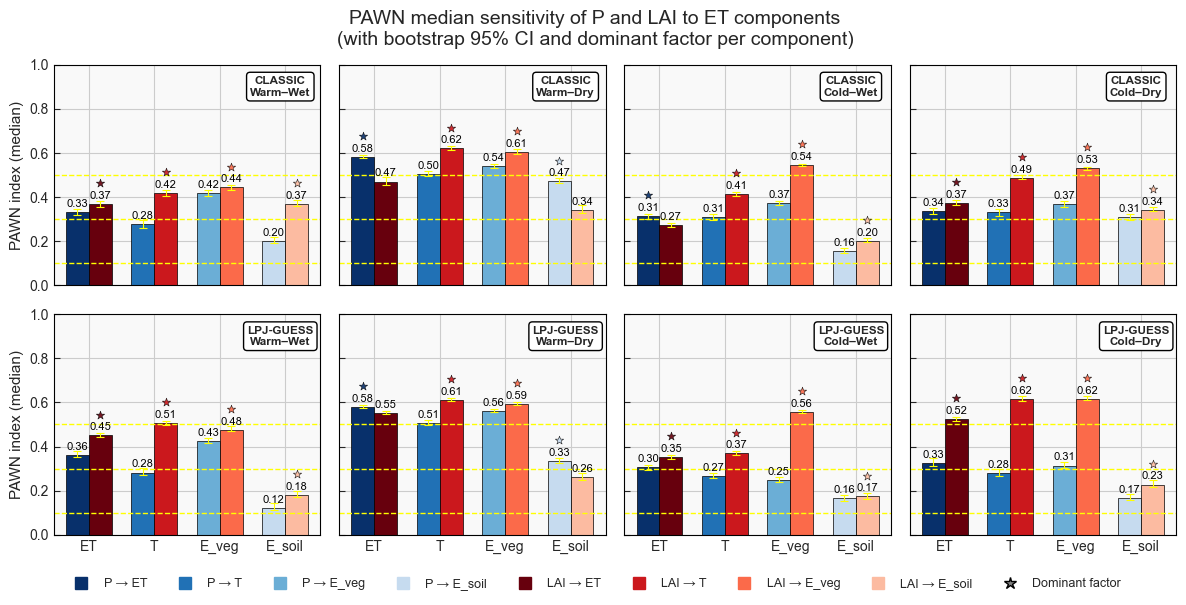

In [181]:
import pandas as pd
from pathlib import Path

# =========================
# 可配置参数
# =========================
output_dir = Path("./output/30mean")         # 导出目录
output_dir.mkdir(parents=True, exist_ok=True)

# 稳定性与显著性阈值（可按需要调整/提升严格性）
CI_WIDTH_THRESHOLD = 0.05                  # 置信区间宽度阈值，<0.05 视为稳定
SIG_LOWER_BOUND_THRESHOLD = 0.10           # 显著性阈值，CI 下限 > 0.10 视为显著
BOOT_STD_THRESHOLD = None                  # 可选：例如 0.02；为 None 时不启用该条件

# 输入/输出变量列表（用于计算每组 Total_Tests）
# 如果后面自动推断的与你项目不一致，可以手动指定：
input_vars = None    # 例如：["precipitation", "lai"]
output_vars = None   # 例如：["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

# =========================
# 读取数据（两种方式二选一）
# =========================
# 方式 A：如果你已有三个 DataFrame，请取消注释并跳过 CSV 读取
# classic_bootstrap_df  # already defined in your session
# lpj_bootstrap_df      # already defined in your session
# all_bootstrap_results # already defined in your session

# 方式 B：从 CSV 读取（按需修改路径）
# 注：如果你只有合并后的 all_bootstrap_results.csv，也可以只读这一份
try:
    classic_bootstrap_df = pd.read_csv(output_dir / 'classic_bootstrap_results.csv')
    lpj_bootstrap_df = pd.read_csv(output_dir / 'lpj_bootstrap_results.csv')
    all_bootstrap_results = pd.read_csv(output_dir / 'all_bootstrap_results.csv')
except Exception:
    # 如果不存在，就尝试从你刚才贴出的表结构创建一个示例 DataFrame
    # 或者这里抛错提醒你提供路径
    # raise FileNotFoundError("Please provide CSVs or preloaded DataFrames.")
    pass

# 如果没有 all_bootstrap_results，就合并 classic / lpj（若存在）
if 'all_bootstrap_results' not in locals():
    dfs = []
    if 'classic_bootstrap_df' in locals():
        dfs.append(classic_bootstrap_df)
    if 'lpj_bootstrap_df' in locals():
        dfs.append(lpj_bootstrap_df)
    if not dfs:
        raise RuntimeError("No input DataFrames found. Provide classic/lpj/all CSVs or variables.")
    all_bootstrap_results = pd.concat(dfs, ignore_index=True)

# =========================
# 字段检查 & 预处理
# =========================
required_cols = [
    "Model","Zone","Output","Input","n_samples",
    "pawn_original","pawn_boot_mean","pawn_boot_std",
    "pawn_ci_lower","pawn_ci_upper"
]
missing = [c for c in required_cols if c not in all_bootstrap_results.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# 若没有现成的显著性列，则根据 CI 下限阈值生成
if "pawn_significant" not in all_bootstrap_results.columns:
    all_bootstrap_results["pawn_significant"] = (
        all_bootstrap_results["pawn_ci_lower"] > SIG_LOWER_BOUND_THRESHOLD
    )

# =========================
# 计算稳定性 / 稳健性
# =========================
all_bootstrap_results["ci_width"] = (
    all_bootstrap_results["pawn_ci_upper"] - all_bootstrap_results["pawn_ci_lower"]
)

stable_by_width = all_bootstrap_results["ci_width"] < CI_WIDTH_THRESHOLD

if BOOT_STD_THRESHOLD is not None:
    stable_by_std = all_bootstrap_results["pawn_boot_std"] < BOOT_STD_THRESHOLD
    all_bootstrap_results["pawn_stable"] = stable_by_width & stable_by_std
else:
    all_bootstrap_results["pawn_stable"] = stable_by_width

all_bootstrap_results["pawn_reliable"] = (
    all_bootstrap_results["pawn_stable"] & all_bootstrap_results["pawn_significant"]
)

# =========================
# 自动推断输入/输出变量列表（如未手动提供）
# =========================
if input_vars is None:
    input_vars = sorted(all_bootstrap_results["Input"].dropna().unique().tolist())
if output_vars is None:
    output_vars = sorted(all_bootstrap_results["Output"].dropna().unique().tolist())

total_tests_per_group = len(input_vars) * len(output_vars)

# =========================
# 分组汇总（Model, Zone）
# =========================
summary_mz = (
    all_bootstrap_results
    .groupby(['Model', 'Zone'], dropna=False)
    .agg(
        PAWN_Significant_Count=('pawn_significant', 'sum'),
        PAWN_Stable_Count=('pawn_stable', 'sum'),
        PAWN_Reliable_Count=('pawn_reliable', 'sum'),
        n_samples=('n_samples', 'first')
    )
    .reset_index()
)

summary_mz["Total_Tests"] = total_tests_per_group
summary_mz["PAWN_Significant_Pct"] = summary_mz["PAWN_Significant_Count"] / summary_mz["Total_Tests"] * 100.0
summary_mz["PAWN_Stable_Pct"]      = summary_mz["PAWN_Stable_Count"]      / summary_mz["Total_Tests"] * 100.0
summary_mz["PAWN_Reliable_Pct"]    = summary_mz["PAWN_Reliable_Count"]    / summary_mz["Total_Tests"] * 100.0

# =========================
# 更细粒度汇总（Model, Zone, Output）
# =========================
summary_mzo = (
    all_bootstrap_results
    .groupby(['Model', 'Zone', 'Output'], dropna=False)
    .agg(
        PAWN_Significant_Count=('pawn_significant', 'sum'),
        PAWN_Stable_Count=('pawn_stable', 'sum'),
        PAWN_Reliable_Count=('pawn_reliable', 'sum')
    )
    .reset_index()
)
summary_mzo["Total_Tests"] = len(input_vars)  # 每个 Output 下测试的输入个数
summary_mzo["PAWN_Significant_Pct"] = summary_mzo["PAWN_Significant_Count"] / summary_mzo["Total_Tests"] * 100.0
summary_mzo["PAWN_Stable_Pct"]      = summary_mzo["PAWN_Stable_Count"]      / summary_mzo["Total_Tests"] * 100.0
summary_mzo["PAWN_Reliable_Pct"]    = summary_mzo["PAWN_Reliable_Count"]    / summary_mzo["Total_Tests"] * 100.0

# =========================
# 导出明细与汇总
# =========================
# 带稳定性/稳健性标记的明细
all_bootstrap_results.to_csv(output_dir / 'all_bootstrap_results_with_stability.csv', index=False)

# 若 classic / lpj 两表在内存里，也分别导出附加了稳定性列的版本
if 'classic_bootstrap_df' in locals():
    classic_aug = all_bootstrap_results[all_bootstrap_results['Model'].str.contains("CLASSIC", na=False)].copy()
    classic_aug.to_csv(output_dir / 'classic_bootstrap_results_with_stability.csv', index=False)

if 'lpj_bootstrap_df' in locals():
    lpj_aug = all_bootstrap_results[all_bootstrap_results['Model'].str.contains("LPJ", na=False)].copy()
    lpj_aug.to_csv(output_dir / 'lpj_bootstrap_results_with_stability.csv', index=False)

# 汇总导出
summary_mz.to_csv(output_dir / 'summary_model_zone.csv', index=False)
summary_mzo.to_csv(output_dir / 'summary_model_zone_output.csv', index=False)

# 兼容你之前的显著性汇总文件名
significance_summary = summary_mz[['Model','Zone','PAWN_Significant_Count','n_samples']].copy()
significance_summary["Total_Tests"] = summary_mz["Total_Tests"]
significance_summary["PAWN_Significant_Pct"] = summary_mz["PAWN_Significant_Pct"]
significance_summary.to_csv(output_dir / 'significance_summary.csv', index=False)

# 终端输出
print("✓ 所有结果已导出到:", output_dir.resolve())
print("\n生成的文件:")
for f in sorted(output_dir.glob('*.csv')):
    print(f"  - {f.name}")

print("\n使用的阈值：")
print(f"  CI width threshold = {CI_WIDTH_THRESHOLD}")
print(f"  Significance lower bound threshold = {SIG_LOWER_BOUND_THRESHOLD}")
print(f"  Boot std threshold = {BOOT_STD_THRESHOLD}")
print(f"  Total tests per (Model, Zone) = {total_tests_per_group}")


✓ 所有结果已导出到: /Users/mimi/Library/CloudStorage/OneDrive-个人/Code/wt/output/30mean

生成的文件:
  - all_bootstrap_results_with_stability.csv
  - classic_bootstrap_results.csv
  - classic_bootstrap_results_with_stability.csv
  - classic_dominant_factors_hsic.csv
  - classic_dominant_factors_pawn.csv
  - classic_gsa_by_zone.csv
  - lpj_bootstrap_results.csv
  - lpj_bootstrap_results_with_stability.csv
  - lpj_dominant_factors_pawn.csv
  - lpj_dominant_factors_src.csv
  - lpj_gsa_by_zone.csv
  - significance_summary.csv
  - summary_model_zone.csv
  - summary_model_zone_output.csv

使用的阈值：
  CI width threshold = 0.05
  Significance lower bound threshold = 0.1
  Boot std threshold = None
  Total tests per (Model, Zone) = 8


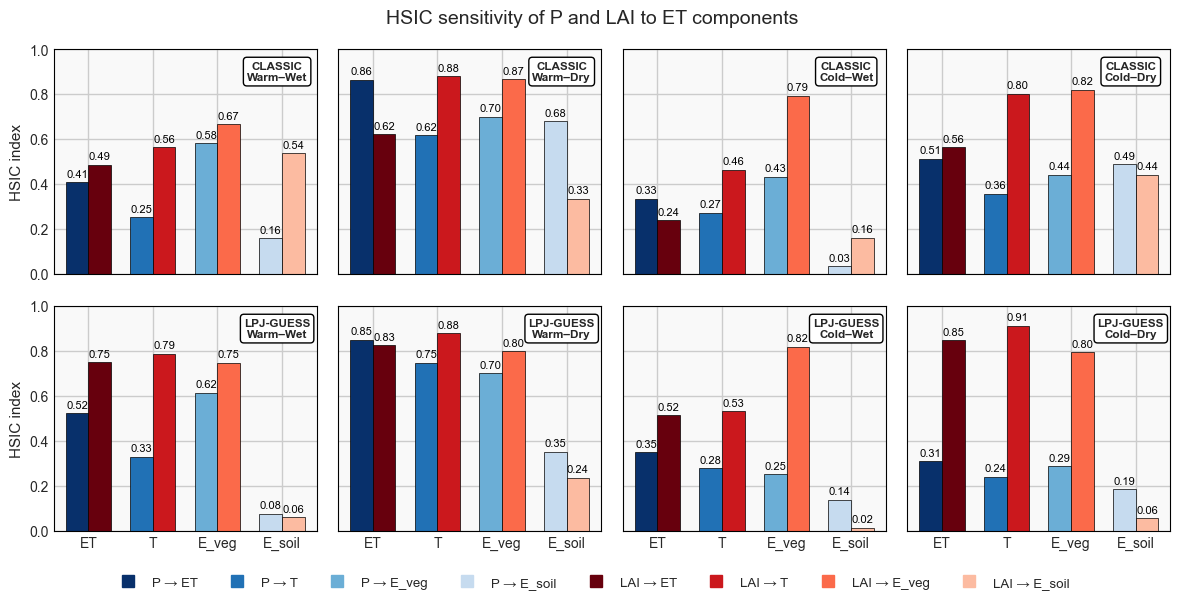

In [196]:
# -*- coding: utf-8 -*-
"""
2×4 HSIC 美化版柱状图
- 每行代表一个模型 (CLASSIC / LPJ-GUESS)
- 每列代表一个气候区 (HW / HD / CW / CD)
- 指标：HSIC
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ========= 0. 文件路径 =========
classic_csv = "./output/30mean/classic_gsa_by_zone.csv"
lpj_csv     = "./output/30mean/lpj_gsa_by_zone.csv"

classic_df = pd.read_csv(classic_csv)
lpj_df     = pd.read_csv(lpj_csv)

cols_keep = ["Output", "Input", "HSIC", "Zone"]
classic_df = classic_df[cols_keep]
lpj_df     = lpj_df[cols_keep]

# ========= 1. 设置 =========
zones = ["HW", "HD", "CW", "CD"]
zone_titles = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}
x_labels = ["ET", "T", "E_veg", "E_soil"]
label_order = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

# P：蓝色系
blues = ["#08306b", "#2171b5", "#6baed6", "#c6dbef"]
# LAI：红色系
reds = ["#67000d", "#cb181d", "#fb6a4a", "#fcbba1"]

mpl.rcParams.update({
    "axes.linewidth": 1.0,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 2. 创建画布 =========
fig, axes = plt.subplots(2, 4, figsize=(12, 6.5), sharey=True)
plt.subplots_adjust(wspace=0.25, hspace=0.35)

bar_width = 0.35
x = np.arange(len(label_order))

# ========= 3. 绘图 =========
for row, (df, model_name) in enumerate(
        [(classic_df, "CLASSIC"),
         (lpj_df,     "LPJ-GUESS")]):

    for col, zone in enumerate(zones):
        ax = axes[row, col]
        sub = df[df["Zone"] == zone]
        pivot = sub.pivot(index="Output", columns="Input", values="HSIC")

        # 背景
        ax.set_facecolor("#f9f9f9")

        for k, out in enumerate(label_order):
            xc = x[k]

            # ----- P -----
            if ("precipitation" in pivot.columns) and (out in pivot.index):
                p_val = pivot.loc[out, "precipitation"]
                bar_p = ax.bar(
                    xc - bar_width/2,
                    p_val,
                    width=bar_width,
                    color=blues[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                ax.text(
                    xc - bar_width/2, p_val + 0.015,
                    f"{p_val:.2f}",
                    ha="center", va="bottom", fontsize=8, color="black",
                    zorder=3
                )

            # ----- LAI -----
            if ("lai" in pivot.columns) and (out in pivot.index):
                l_val = pivot.loc[out, "lai"]
                bar_l = ax.bar(
                    xc + bar_width/2,
                    l_val,
                    width=bar_width,
                    color=reds[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                ax.text(
                    xc + bar_width/2, l_val + 0.015,
                    f"{l_val:.2f}",
                    ha="center", va="bottom", fontsize=8, color="black",
                    zorder=3
                )

        # 坐标样式
        ax.set_xticks(x)
        ax.set_ylim(0, 1.0)
        ax.tick_params(axis="both", direction="in", length=4, width=0.8)

        # 第一行去掉 x 轴标签，第二行保留
        if row == 0:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels(x_labels)

        # y 轴
        if col == 0:
            ax.set_ylabel("HSIC index")
        else:
            ax.set_ylabel("")

        # 内嵌标题
        ax.text(
            0.85, 0.9, f"{model_name}\n{zone_titles[zone]}",
            transform=ax.transAxes,
            fontsize=8.5, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
            ha="center", va="center",
            zorder=5
        )

        # 边框
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(0.8)

# ========= 4. 图例（单行） =========
label_order = ["ET", "T", "E_veg", "E_soil"]
legend_handles = []

for lbl, color in zip(label_order, blues):
    legend_handles.append(Line2D([], [], color=color, marker="s", linestyle="None",
                                 markersize=8, label=f"P → {lbl}"))
for lbl, color in zip(label_order, reds):
    legend_handles.append(Line2D([], [], color=color, marker="s", linestyle="None",
                                 markersize=8, label=f"LAI → {lbl}"))

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=8,
    frameon=False,
    fontsize=9.5,
    bbox_to_anchor=(0.5, 0.01),
)

# ========= 5. 总标题 =========
fig.suptitle(
    "HSIC sensitivity of P and LAI to ET components",
    fontsize=14, y=0.92
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

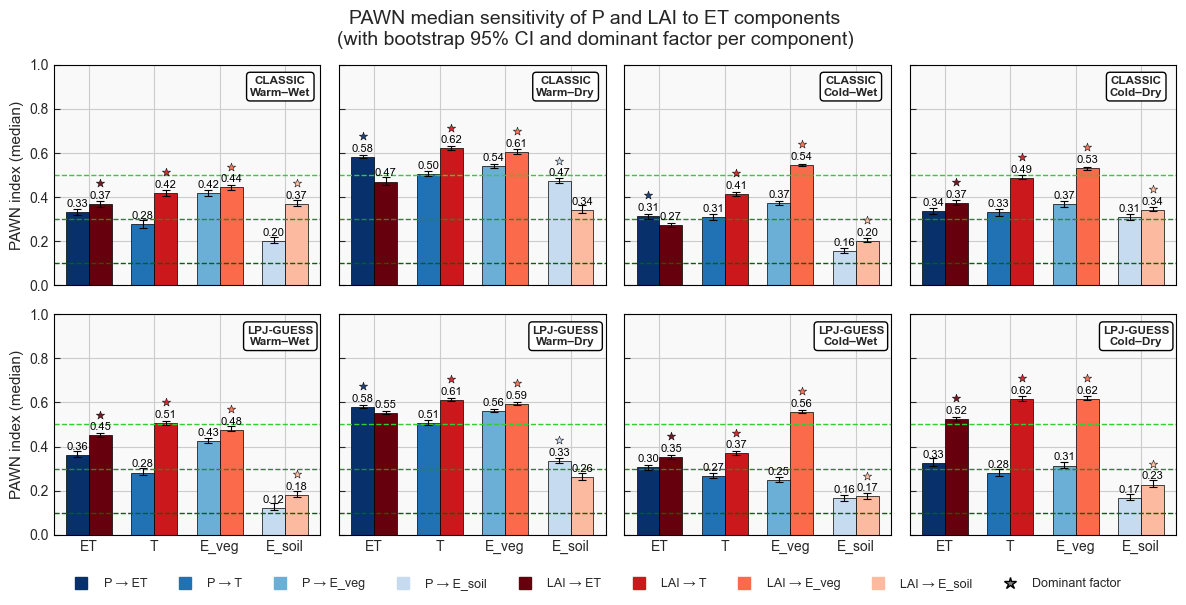

In [5]:
# -*- coding: utf-8 -*-
"""
2×4 美化版柱状图 + 置信区间 + 主控因素标记
- 行：CLASSIC / LPJ-GUESS
- 列：HW / HD / CW / CD
- 每组双柱：左 P、右 LAI（PAWN median）
- 置信区间来自 bootstrap 结果
- 主控因素来自 dominant_factors_pawn.csv，用星号标在对应柱子上方（不遮挡数字）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ========= 0. 文件路径 =========
classic_csv       = "./output/30mean/classic_gsa_by_zone.csv"
lpj_csv           = "./output/30mean/lpj_gsa_by_zone.csv"
classic_boot_csv  = "./output/30mean/classic_bootstrap_results.csv"
lpj_boot_csv      = "./output/30mean/lpj_bootstrap_results.csv"
classic_dom_csv   = "./output/30mean/classic_dominant_factors_pawn.csv"
lpj_dom_csv       = "./output/30mean/lpj_dominant_factors_pawn.csv"

# ========= 1. 读入数据 =========
# 主数据（PAWN median，用来画柱）
cols_keep = ["Output", "Input", "PAWN_median", "Zone"]
classic_df = pd.read_csv(classic_csv)[cols_keep]
lpj_df     = pd.read_csv(lpj_csv)[cols_keep]

# bootstrap 结果（置信区间）
boot_keep = ["Zone", "Output", "Input", "pawn_ci_lower", "pawn_ci_upper"]
classic_boot = pd.read_csv(classic_boot_csv)[boot_keep]
lpj_boot     = pd.read_csv(lpj_boot_csv)[boot_keep]

# 主控因素结果
# 列：Zone,Output,Dominant_Factor,Precip_Value,LAI_Value,Dominance_Ratio
classic_dom = pd.read_csv(classic_dom_csv)
lpj_dom     = pd.read_csv(lpj_dom_csv)

# ========= 2. 配置 =========
zones = ["HW", "HD", "CW", "CD"]
zone_titles = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}
x_labels    = ["ET", "T", "E_veg", "E_soil"]
label_order = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

# P：蓝色系
blues = ["#08306b", "#2171b5", "#6baed6", "#c6dbef"]
# LAI：红色系
reds  = ["#67000d", "#cb181d", "#fb6a4a", "#fcbba1"]

mpl.rcParams.update({
    "axes.linewidth": 1.0,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 3. 画布 =========
fig, axes = plt.subplots(2, 4, figsize=(12, 6.5), sharey=True)
plt.subplots_adjust(wspace=0.25, hspace=0.35)

bar_width   = 0.35
x           = np.arange(len(label_order))
y_min, y_max = 0.0, 1.0
num_offset  = 0.015   # 数字离柱顶的距离
star_offset = 0.08    # 星号再比数字高一点

# ========= 4. 绘图主循环 =========
for row, (df, boot_df, dom_df, model_name) in enumerate(
    [
        (classic_df, classic_boot, classic_dom, "CLASSIC"),
        (lpj_df,     lpj_boot,     lpj_dom,     "LPJ-GUESS"),
    ]
):
    for col, zone in enumerate(zones):
        ax = axes[row, col]

        sub      = df[df["Zone"] == zone]
        boot_sub = boot_df[boot_df["Zone"] == zone]
        dom_sub  = dom_df[dom_df["Zone"] == zone]

        # pivot: index=Output, columns=Input, values=PAWN_median
        pivot = sub.pivot(index="Output", columns="Input", values="PAWN_median")

        # 背景
        ax.set_facecolor("#f9f9f9")

        for k, out in enumerate(label_order):
            xc = x[k]

            # 这一行的主控信息（可能为空）
            dom_row = dom_sub[dom_sub["Output"] == out]
            dominant_factor = dom_row["Dominant_Factor"].iloc[0] if not dom_row.empty else None
            dom_factor_lower = dominant_factor.lower() if dominant_factor is not None else ""

            # ---- P 柱 ----
            if ("precipitation" in pivot.columns) and (out in pivot.index):
                p_val = pivot.loc[out, "precipitation"]

                # 柱
                ax.bar(
                    xc - bar_width/2,
                    p_val,
                    width=bar_width,
                    color=blues[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                # 数值
                ax.text(
                    xc - bar_width/2,
                    p_val + num_offset,
                    f"{p_val:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="black",
                    zorder=3,
                )

                # CI
                ci_p = boot_sub[
                    (boot_sub["Output"] == out) &
                    (boot_sub["Input"] == "precipitation")
                ]
                if not ci_p.empty:
                    lower = ci_p["pawn_ci_lower"].iloc[0]
                    upper = ci_p["pawn_ci_upper"].iloc[0]
                    yerr  = [[p_val - lower], [upper - p_val]]
                    ax.errorbar(
                        xc - bar_width/2,
                        p_val,
                        yerr=yerr,
                        fmt="none",
                        ecolor="black",
                        elinewidth=0.8,
                        capsize=3,
                        capthick=0.8,
                        zorder=4,
                    )
            else:
                p_val = None

            # ---- LAI 柱 ----
            if ("lai" in pivot.columns) and (out in pivot.index):
                l_val = pivot.loc[out, "lai"]
                ax.bar(
                    xc + bar_width/2,
                    l_val,
                    width=bar_width,
                    color=reds[k],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                ax.text(
                    xc + bar_width/2,
                    l_val + num_offset,
                    f"{l_val:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="black",
                    zorder=3,
                )

                ci_l = boot_sub[
                    (boot_sub["Output"] == out) &
                    (boot_sub["Input"] == "lai")
                ]
                if not ci_l.empty:
                    lower = ci_l["pawn_ci_lower"].iloc[0]
                    upper = ci_l["pawn_ci_upper"].iloc[0]
                    yerr  = [[l_val - lower], [upper - l_val]]
                    ax.errorbar(
                        xc + bar_width/2,
                        l_val,
                        yerr=yerr,
                        fmt="none",
                        ecolor="black",
                        elinewidth=0.8,
                        capsize=3,
                        capthick=0.8,
                        zorder=4,
                    )
            else:
                l_val = None

            # ---- 主控因素星号（放在数字上方，不遮挡） ----
            if dominant_factor is not None:
                if "precip" in dom_factor_lower and p_val is not None:
                    x_dom = xc - bar_width/2
                    y_dom = p_val
                    star_color = blues[k]   # P 主导：用蓝色星
                elif "lai" in dom_factor_lower and l_val is not None:
                    x_dom = xc + bar_width/2
                    y_dom = l_val
                    star_color = reds[k]    # LAI 主导：用红色星
                else:
                    x_dom, y_dom, star_color = None, None, None

                if x_dom is not None:
                    y_star = y_dom + num_offset + star_offset
                    # 防止超过 y_max
                    y_star = min(y_star, y_max - 0.02)
                    ax.scatter(
                        x_dom,
                        y_star,
                        marker="*",
                        s=40,
                        color=star_color,
                        edgecolors="black",
                        linewidths=0.4,
                        alpha=0.9,
                        zorder=6,
                    )

        # ==== 坐标样式 ====
        ax.set_xticks(x)
        ax.set_ylim(y_min, y_max)
        ax.tick_params(axis="both", direction="in", length=4, width=0.8)

        # 第一行不显示 x 轴刻度文字；第二行显示
        if row == 0:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels(x_labels)

        # y 轴
        if col == 0:
            ax.set_ylabel("PAWN index (median)")
        else:
            ax.set_ylabel("")

        # 内嵌标题
        ax.text(
            0.85,
            0.9,
            f"{model_name}\n{zone_titles[zone]}",
            transform=ax.transAxes,
            fontsize=8.5,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                edgecolor="black",
                boxstyle="round,pad=0.3"
            ),
            ha="center",
            va="center",
            zorder=5,
        )

        # 边框
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(0.8)

        # 在y轴上标记 0.1、0.3、0.5
        ax.axhline(y=0.1, color="#006400", linestyle="--", lw=1)
        ax.axhline(y=0.3, color="#228B22", linestyle="--", lw=1)
        ax.axhline(y=0.5, color="#32CD32", linestyle="--", lw=1)

# ========= 5. 图例 =========
disp_labels = ["ET", "T", "E_veg", "E_soil"]

legend_handles = []
# P 系列（蓝）
for lbl, color in zip(disp_labels, blues):
    legend_handles.append(
        Line2D([], [], color=color, marker="s", linestyle="None",
               markersize=8, label=f"P → {lbl}")
    )
# LAI 系列（红）
for lbl, color in zip(disp_labels, reds):
    legend_handles.append(
        Line2D([], [], color=color, marker="s", linestyle="None",
               markersize=8, label=f"LAI → {lbl}")
    )
# 主控星号（用黑边星作为示例）
legend_handles.append(
    Line2D([], [], color="white", marker="*", markerfacecolor="gray",
           markeredgecolor="black", linestyle="None", markersize=9,
           label="Dominant factor")
)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=9,                 # 8 个箭头 + 1 个星
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, 0.01),
)

# ========= 6. 总标题 =========
fig.suptitle(
    "PAWN median sensitivity of P and LAI to ET components\n"
    "(with bootstrap 95% CI and dominant factor per component)",
    fontsize=14,
    y=0.92,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

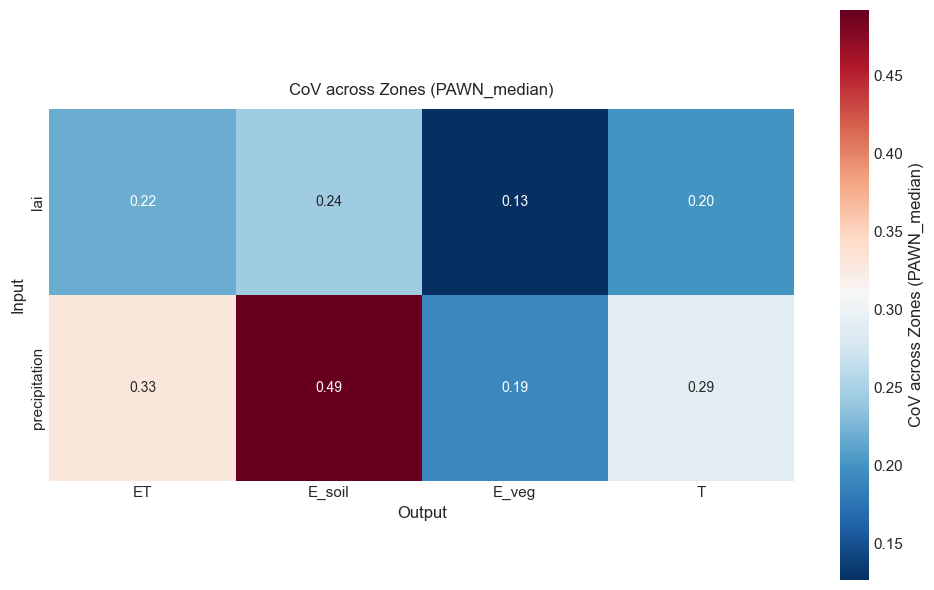

⚠️ 未检测到 'Model' 列：只能计算 'CoV across Zones'，无法计算 'CoV across Models'。


In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ========= 参数 =========
csv_path = "./output/30mean/classic_gsa_by_zone.csv"  # 替换为你的文件路径
metric   = "PAWN_median"               # 可选: "PAWN_median","PAWN_max","HSIC","SRC","R2"
inputs_keep = ["precipitation", "lai"] # 仅保留关心的输入（可改）
out_label_map = {
    "evapotrans": "ET",
    "tran": "T",
    "evspsblveg": "E_veg",
    "evspsblsoi": "E_soil",
}
desired_cols = ["ET", "E_soil", "E_veg", "T"]  # 热力图列顺序

# ========= 读取与预处理 =========
df = pd.read_csv(csv_path)

# 基本列检查
base_cols = {"Output", "Input", "Zone", metric}
missing = base_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV 缺少必要列: {missing}")

has_model = "Model" in df.columns

# 仅保留指定输入
if inputs_keep:
    df = df[df["Input"].isin(inputs_keep)].copy()

# 统一输出标签
df["Output_label"] = df["Output"].map(out_label_map).fillna(df["Output"])

# ========= 1) 同一模型内，跨 Zone 的 CoV（Across Zones）=========
# 分组键：有 Model 列则包含 Model，否则不包含
group_keys = (["Model", "Input", "Output_label"] if has_model
              else ["Input", "Output_label"])

# 在 Zone 维度上统计 mean/std/count → CoV = std/mean
agg_z = (df
         .groupby(group_keys, dropna=False)[metric]
         .agg(mean_metric="mean",
              std_metric=lambda x: x.std(ddof=1),
              n_groups="count")
         .reset_index())
agg_z["CoV_across_Zones"] = np.where(agg_z["mean_metric"].abs() > 0,
                                     agg_z["std_metric"] / agg_z["mean_metric"],
                                     np.nan)

# 生成8x4热力图
if has_model:
    # 每个模型单独画一张
    for m, sub in agg_z.groupby("Model"):
        pivot = sub.pivot_table(index="Input", columns="Output_label",
                                values="CoV_across_Zones")
        pivot = pivot.reindex(columns=[c for c in desired_cols if c in pivot.columns])

        plt.figure(figsize=(10, 6))  # 调整图的尺寸，确保热力图较大
        ax = sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r",
                         cbar_kws={"label": f"CoV across Zones ({metric})"},
                         square=True, linewidths=0)
        ax.set_title(f"CoV across Zones per Model = {m}  ({metric})", fontsize=12, pad=10)
        ax.set_xlabel("Output"); ax.set_ylabel("Input")
        plt.tight_layout()
        plt.show()  # Display heatmap without saving
else:
    pivot = agg_z.pivot_table(index="Input", columns="Output_label",
                              values="CoV_across_Zones")
    pivot = pivot.reindex(columns=[c for c in desired_cols if c in pivot.columns])

    plt.figure(figsize=(10, 6))  # 调整图的尺寸，确保热力图较大
    ax = sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r",
                     cbar_kws={"label": f"CoV across Zones ({metric})"},
                     square=True, linewidths=0)
    ax.set_title(f"CoV across Zones ({metric})", fontsize=12, pad=10)
    ax.set_xlabel("Output"); ax.set_ylabel("Input")
    plt.tight_layout()
    plt.show()  # Display heatmap without saving

# ========= 2) 同一 Zone 内，跨 Model 的 CoV（Across Models）=========
if has_model:
    group_keys2 = ["Zone", "Input", "Output_label"]
    agg_m = (df
             .groupby(group_keys2, dropna=False)[metric]
             .agg(mean_metric="mean",
                  std_metric=lambda x: x.std(ddof=1),
                  n_groups="count")
             .reset_index())
    agg_m["CoV_across_Models"] = np.where(agg_m["mean_metric"].abs() > 0,
                                          agg_m["std_metric"] / agg_m["mean_metric"],
                                          np.nan)

    # 展示每个 Zone 的热力图
    for z, sub in agg_m.groupby("Zone"):
        pivot = sub.pivot_table(index="Input", columns="Output_label",
                                values="CoV_across_Models")
        pivot = pivot.reindex(columns=[c for c in desired_cols if c in pivot.columns])

        plt.figure(figsize=(10, 6))  # 调整图的尺寸，确保热力图较大
        ax = sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r",
                         cbar_kws={"label": f"CoV across Models ({metric})"},
                         square=True, linewidths=0)
        ax.set_title(f"CoV across Models per Zone = {z}  ({metric})", fontsize=12, pad=10)
        ax.set_xlabel("Output"); ax.set_ylabel("Input")
        plt.tight_layout()
        plt.show()  # Display heatmap without saving
else:
    print("⚠️ 未检测到 'Model' 列：只能计算 'CoV across Zones'，无法计算 'CoV across Models'。")

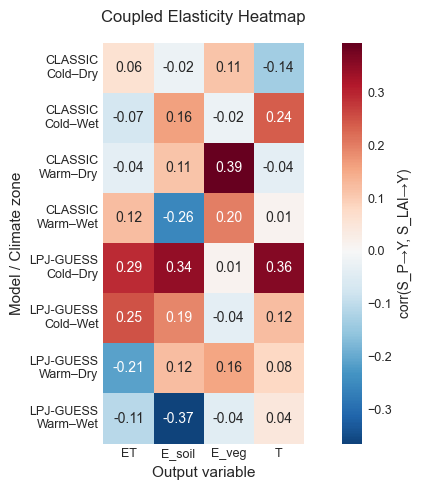

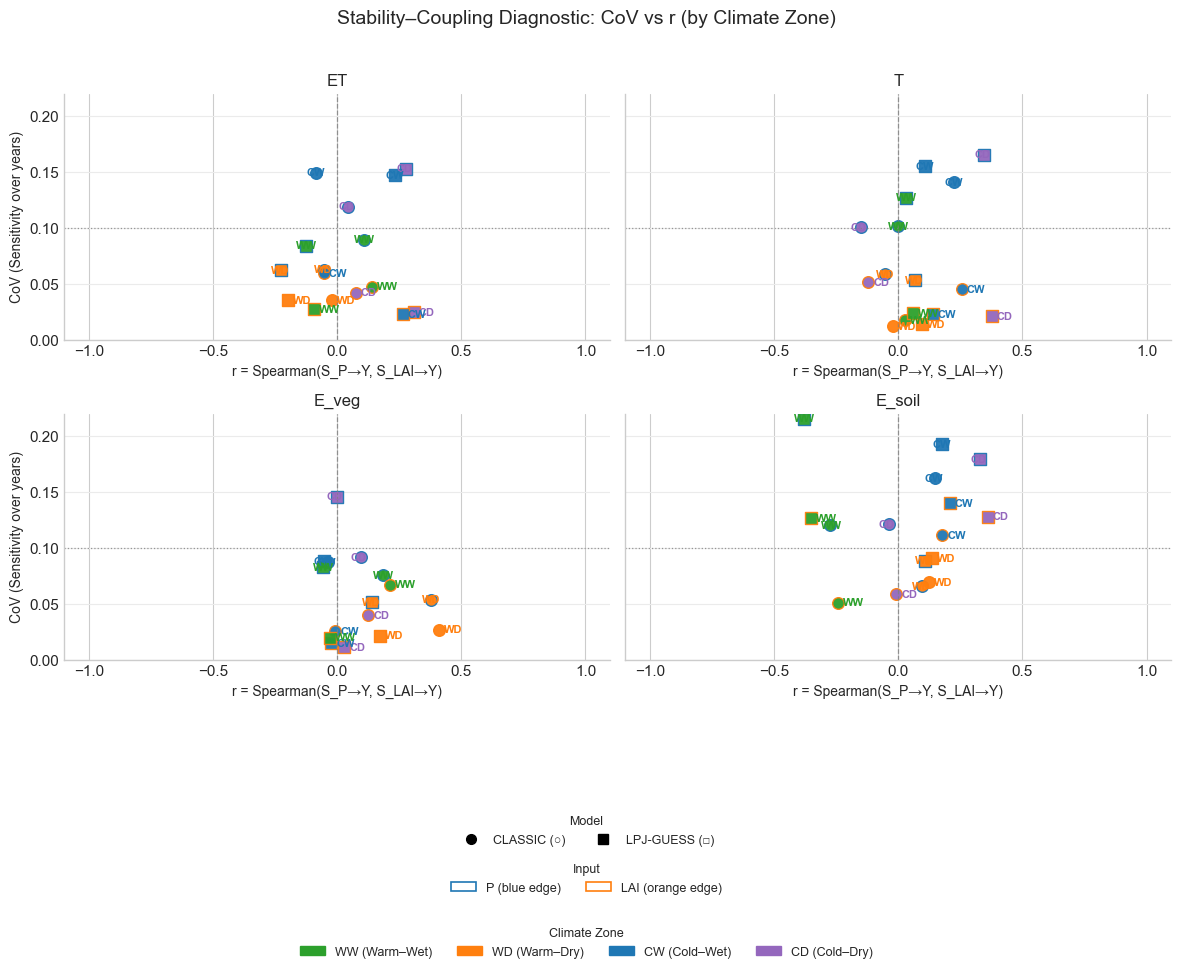

In [38]:
# -*- coding: utf-8 -*-
"""
绘制 P 与 LAI 对各通量敏感性“协同 + 稳定性”诊断
- 图1：corr_t( S_{P→Y}(t), S_{LAI→Y}(t) ) —— Spearman（敏感性协同/竞争）
- 图2：CoV–r 诊断图（y=CoV(std/mean)，x=r；分别显示 P→Y 与 LAI→Y）
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ========= 1. 读取 PAWN 结果 =========
df = pd.read_csv("./output/30y_pawn/all_30y_pawn_results.csv")
df["year"] = df["year"].astype(int)
df = df[df["input_var"].isin(["precipitation", "lai"])]

outputs = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]
out_label_map = {
    "evapotrans": "ET",
    "tran": "T",
    "evspsblveg": "E_veg",
    "evspsblsoi": "E_soil",
}

# ========= 2. 计算 corr(S_P→Y, S_LAI→Y) =========
group_cols = ["model", "climate_zone", "output_var"]
rows_corr = []
rows_cov  = []

for keys, sub in df.groupby(group_cols):
    model, zone, outvar = keys
    out_label = out_label_map.get(outvar, outvar)

    # 同一组内：year × input_var 的敏感性时间序列
    ts = (
        sub.pivot_table(index="year", columns="input_var", values="pawn_median")
          .reindex(columns=["precipitation","lai"])
          .dropna()
    )

    # ---- r：敏感性之间的 Spearman 相关（协同/竞争）
    r_val = np.nan
    if ts.shape[0] > 2:
        r_val = ts.corr(method="spearman").loc["precipitation", "lai"]

    rows_corr.append({
        "model": model,
        "climate_zone": zone,
        "output_label": out_label,
        "r_SPY_SLAIY": r_val
    })

    # ---- CoV：对 P→Y 与 LAI→Y 各自的年际 CoV（稳定性）
    # CoV = std/mean（加微小epsilon防除零）
    eps = 1e-12
    cov_p = np.nan
    cov_l = np.nan
    if ts.shape[0] >= 3:
        sP = ts["precipitation"].dropna()
        sL = ts["lai"].dropna()
        if sP.size >= 3 and abs(sP.mean()) > 0:
            cov_p = sP.std(ddof=1) / (abs(sP.mean()) + eps)
        if sL.size >= 3 and abs(sL.mean()) > 0:
            cov_l = sL.std(ddof=1) / (abs(sL.mean()) + eps)

    rows_cov.append({
        "model": model,
        "climate_zone": zone,
        "output_label": out_label,
        "CoV_P_to_Y": cov_p,
        "CoV_LAI_to_Y": cov_l
    })

corr_df = pd.DataFrame(rows_corr)
cov_df  = pd.DataFrame(rows_cov)

# 合并成诊断表
diag = (corr_df.merge(cov_df, on=["model","climate_zone","output_label"], how="left")
                 .sort_values(["model","climate_zone","output_label"]))

# ========= 3. 图1：相关热力图（和你原来一致）=========
pivot = corr_df.pivot_table(
    index=["model", "climate_zone"],
    columns="output_label",
    values="r_SPY_SLAIY"
)

zone_fullname = {"HW":"Warm–Wet","HD":"Warm–Dry","CW":"Cold–Wet","CD":"Cold–Dry"}
pivot.index = [f"{m}\n{zone_fullname.get(z, z)}" for (m, z) in pivot.index]

plt.figure(figsize=(8, 5))
ax = sns.heatmap(
    pivot, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0.0,
    square=True, cbar_kws={"label": "Spearman( S_P→Y , S_LAI→Y )"},
    linewidths=0
)
ax.set_xlabel("Output variable", fontsize=11)
ax.set_ylabel("Model / Climate zone", fontsize=11)
ax.set_title("Coupled Elasticity Heatmap", fontsize=12, pad=15)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)
cbar.set_label("corr(S_P→Y, S_LAI→Y)", fontsize=10)
for lab in ax.get_xticklabels() + ax.get_yticklabels():
    lab.set_fontsize(9)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()
# ========= 图2：CoV–r 诊断图（2×2布局 + x轴放宽 + 防重叠 + 分层图例）=========
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

outputs_order = ["ET", "T", "E_veg", "E_soil"]
zone_color = {"Warm–Wet":"#2ca02c","Warm–Dry":"#ff7f0e","Cold–Wet":"#1f77b4","Cold–Dry":"#9467bd"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=True)
axes = axes.ravel()

# 全局y范围
ymax = float(np.nanmax(diag[["CoV_P_to_Y","CoV_LAI_to_Y"]].values)) + 0.01
ymax = max(0.16, min(0.22, ymax))  # 合理上限
delta = 0.03  # P/LAI 水平错位，避免与r=0竖线重叠

for i, out_label in enumerate(outputs_order):
    ax = axes[i]
    sub = diag[diag["output_label"] == out_label].copy()

    # 参考线
    ax.axvline(0, ls="--", lw=0.9, color="gray", alpha=0.8)
    ax.axhline(0.10, ls=":", lw=0.9, color="gray", alpha=0.8)

    # 散点：给 P/LAI 加水平偏移 ±delta/2
    for src, edgecol, label_prefix, shift in [
        ("CoV_P_to_Y",  "#1f77b4", "P",   -delta/2),
        ("CoV_LAI_to_Y","#ff7f0e", "LAI", +delta/2),
    ]:
        for model, marker in [("CLASSIC","o"), ("LPJ-GUESS","s")]:
            d = sub[sub["model"] == model].copy()
            for _, row in d.iterrows():
                zone_full = zone_fullname.get(row["climate_zone"], row["climate_zone"])
                short_zone = "".join([w[0] for w in zone_full.split("–")])
                x = row["r_SPY_SLAIY"]
                y = row[src]
                if pd.notna(x) and pd.notna(y):
                    ax.scatter(x + shift, y, s=70, marker=marker,
                               facecolor=zone_color.get(zone_full, "gray"),
                               edgecolor=edgecol, linewidth=1.0, alpha=0.95)
                    # 标签：随 P/LAI 朝外微偏，减少遮挡
                    ax.text(x + shift + (0.02 if shift>0 else -0.04), y,
                            short_zone, fontsize=8,
                            color=zone_color.get(zone_full, "gray"), weight="bold",
                            va="center")

    # 轴样式
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(0.00, ymax)
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax.grid(axis="y", color="0.92", lw=0.8)
    for sp in ["top","right"]:
        ax.spines[sp].set_visible(False)
    ax.set_title(out_label, fontsize=12, pad=6)
    ax.set_xlabel("r = Spearman(S_P→Y, S_LAI→Y)", fontsize=10)
    if i % 2 == 0:  # 左列显示y轴标题
        ax.set_ylabel("CoV (Sensitivity over years)", fontsize=10)

# —— 分层图例：模型形状 / 输入边框色 / 气候区颜色
model_legend = [
    mlines.Line2D([], [], color="black", marker="o", linestyle="None", markersize=7, label="CLASSIC (○)"),
    mlines.Line2D([], [], color="black", marker="s", linestyle="None", markersize=7, label="LPJ-GUESS (□)")
]
input_legend = [
    mpatches.Patch(facecolor="white", edgecolor="#1f77b4", linewidth=1.2, label="P (blue edge)"),
    mpatches.Patch(facecolor="white", edgecolor="#ff7f0e", linewidth=1.2, label="LAI (orange edge)")
]
zone_legend = [
    mpatches.Patch(color=zone_color["Warm–Wet"],  label="WW (Warm–Wet)"),
    mpatches.Patch(color=zone_color["Warm–Dry"],  label="WD (Warm–Dry)"),
    mpatches.Patch(color=zone_color["Cold–Wet"],  label="CW (Cold–Wet)"),
    mpatches.Patch(color=zone_color["Cold–Dry"],  label="CD (Cold–Dry)")
]

leg1 = fig.legend(handles=model_legend, loc="lower center", bbox_to_anchor=(0.5, -0.08),
                  ncol=2, frameon=False, fontsize=9, title="Model", title_fontsize=9)
leg2 = fig.legend(handles=input_legend, loc="lower center", bbox_to_anchor=(0.5, -0.14),
                  ncol=2, frameon=False, fontsize=9, title="Input", title_fontsize=9)
leg3 = fig.legend(handles=zone_legend,  loc="lower center", bbox_to_anchor=(0.5, -0.22),
                  ncol=4, frameon=False, fontsize=9, title="Climate Zone", title_fontsize=9)

plt.suptitle("Stability–Coupling Diagnostic: CoV vs r (by Climate Zone)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0.10, 1, 0.96])  # 留出底部空间摆放三个图例
plt.show()


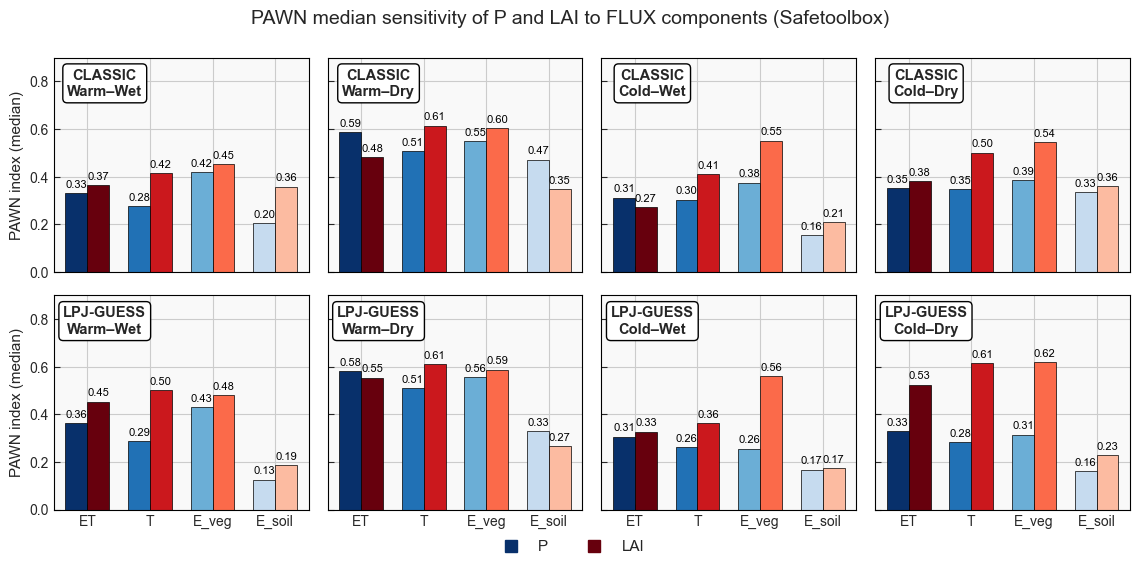

In [40]:
# -*- coding: utf-8 -*-
"""
2×4 HSIC 美化版柱状图
- 每行代表一个模型 (CLASSIC / LPJ-GUESS)
- 每列代表一个气候区 (HW / HD / CW / CD)
- 指标：HSIC
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ========= 0. 文件路径 =========
classic_csv = "./output/30mean/safetoolbox/classic_pawn_safetoolbox_by_zone.csv"
lpj_csv     = "./output/30mean/safetoolbox/lpj_pawn_safetoolbox_by_zone.csv"

# -*- coding: utf-

classic_df = pd.read_csv(classic_csv)
lpj_df     = pd.read_csv(lpj_csv)

cols_keep = ["Output", "Input", "PAWN_median", "Zone"]
classic_df = classic_df[cols_keep]
lpj_df     = lpj_df[cols_keep]

# ========= 1. 设置 =========
zones = ["HW", "HD", "CW", "CD"]
zone_titles = {
    "HW": "Warm–Wet",
    "HD": "Warm–Dry",
    "CW": "Cold–Wet",
    "CD": "Cold–Dry",
}
x_labels = ["ET", "T", "E_veg", "E_soil"]
label_order = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

# P：蓝色系
blues = ["#08306b", "#2171b5", "#6baed6", "#c6dbef"]
# LAI：红色系
reds = ["#67000d", "#cb181d", "#fb6a4a", "#fcbba1"]

mpl.rcParams.update({
    "axes.linewidth": 1.0,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 2. 创建画布 =========
fig, axes = plt.subplots(2, 4, figsize=(11.5, 6), sharey=True)
plt.subplots_adjust(wspace=0.25, hspace=0.35)

bar_width = 0.35
x = np.arange(len(label_order))

# ========= 3. 绘图 =========
for row, (df, model_name) in enumerate([(classic_df, "CLASSIC"), (lpj_df, "LPJ-GUESS")]):
    for col, zone in enumerate(zones):
        ax = axes[row, col]
        sub = df[df["Zone"] == zone]
        pivot = sub.pivot(index="Output", columns="Input", values="PAWN_median")

        # 背景
        ax.set_facecolor("#f9f9f9")

        for k, out in enumerate(label_order):
            xc = x[k]
            p_val = pivot.loc[out, "precipitation"] if ("precipitation" in pivot.columns and out in pivot.index) else np.nan
            l_val = pivot.loc[out, "lai"] if ("lai" in pivot.columns and out in pivot.index) else np.nan

            if not np.isnan(p_val):
                bar_p = ax.bar(
                    xc - bar_width/2,
                    p_val,
                    width=bar_width,
                    color=blues[k],
                    edgecolor="black",
                    linewidth=0.5,
                )
                ax.text(
                    xc - bar_width/2, p_val + 0.015,
                    f"{p_val:.2f}",
                    ha="center", va="bottom", fontsize=8, color="black"
                )
            if not np.isnan(l_val):
                bar_l = ax.bar(
                    xc + bar_width/2,
                    l_val,
                    width=bar_width,
                    color=reds[k],
                    edgecolor="black",
                    linewidth=0.5,
                )
                ax.text(
                    xc + bar_width/2, l_val + 0.015,
                    f"{l_val:.2f}",
                    ha="center", va="bottom", fontsize=8, color="black"
                )

        # 坐标样式
        ax.set_xticks(x)
        ax.set_ylim(0, 0.9)
        ax.tick_params(axis="both", direction="in", length=4, width=0.8)

        # ✅ 第一行去掉 x 轴标签
        if row == 0:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels(x_labels)

        # y轴
        if col == 0:
            ax.set_ylabel("PAWN index (median)")
        else:
            ax.set_ylabel("")

        # ==== 内嵌标题 ====
        ax.text(
            0.2, 0.88, f"{model_name}\n{zone_titles[zone]}",
            transform=ax.transAxes,
            fontsize=10.5, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
            ha="center", va="center"
        )

        # 边框
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(0.8)

# ========= 4. 图例 =========
legend_handles = [
    Line2D([], [], color=blues[0], marker="s", linestyle="None", markersize=8, label="P"),
    Line2D([], [], color=reds[0], marker="s", linestyle="None", markersize=8, label="LAI"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.02),
)

# ========= 5. 总标题 =========
fig.suptitle(
    "PAWN median sensitivity of P and LAI to FLUX components (Safetoolbox)",
    fontsize=14, y=0.95
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

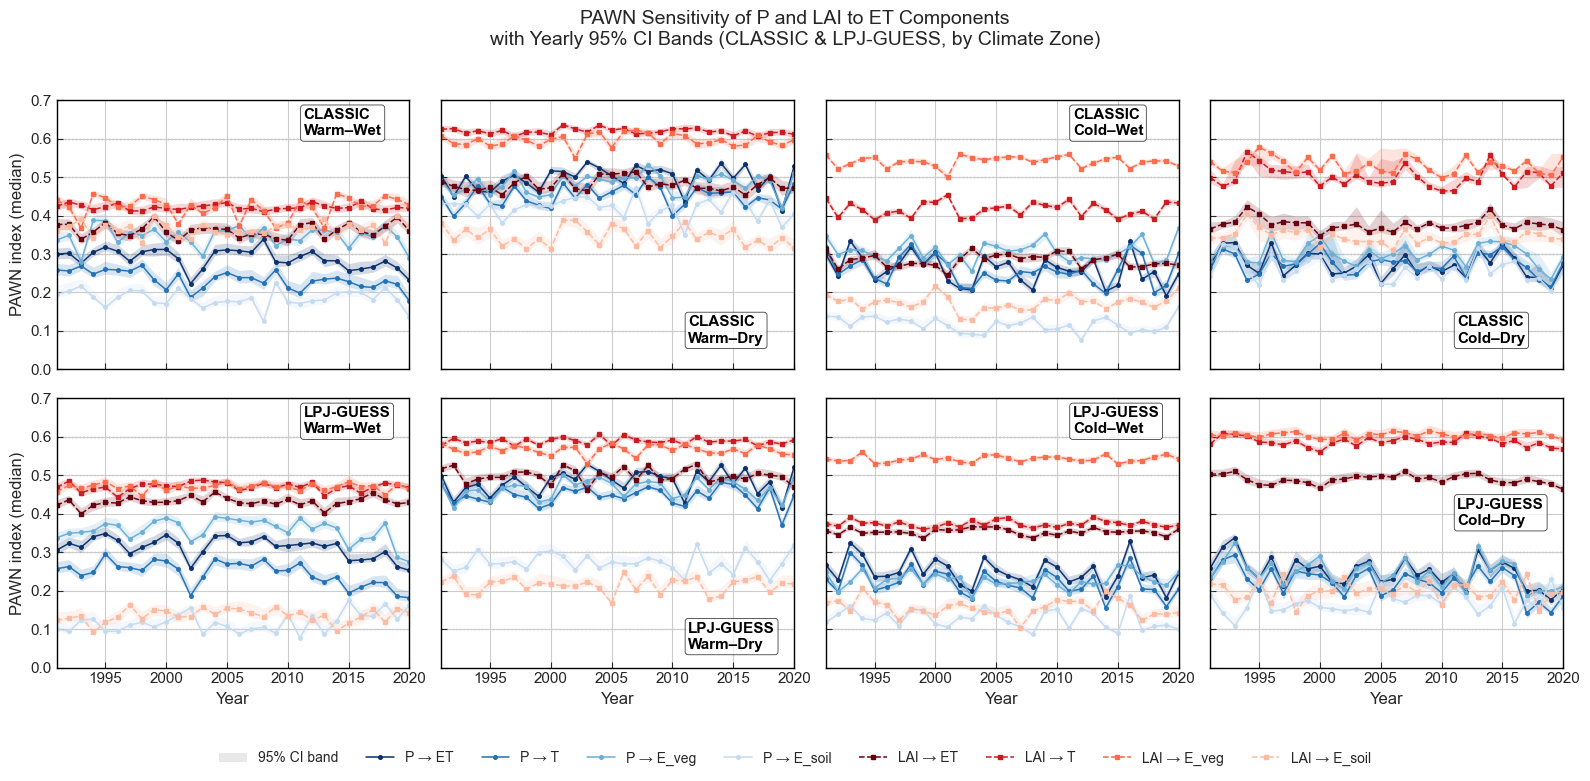

In [57]:
# -*- coding: utf-8 -*-
"""
2×4 图（带逐年CI阴影带）：
第一行：CLASSIC 四个气候区
第二行：LPJ-GUESS 四个气候区
每图 8 条折线：P→蓝色系, LAI→红色系；并为每条线绘制逐年CI阴影带
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ========= 1) 读取数据 =========
main_csv = "./output/30y_pawn/all_30y_pawn_results.csv"
ci_csv   = "./output/30y_pawn/all_bootstrap_30y_results.csv"   # ← 替换成你的逐年CI文件名

df = pd.read_csv(main_csv)
ci = pd.read_csv(ci_csv)

# 统一类型 & 过滤
df["year"] = df["year"].astype(int)
ci["year"] = ci["year"].astype(int)
df = df[df["input_var"].isin(["precipitation", "lai"])]

# ========= 2) 参数 =========
models  = ["CLASSIC", "LPJ-GUESS"]
zones   = ["HW", "HD", "CW", "CD"]
outputs = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]

zone_titles = {"HW":"Warm–Wet","HD":"Warm–Dry","CW":"Cold–Wet","CD":"Cold–Dry"}

# 颜色（与原图一致）
blues = ["#08306b","#2171b5","#6baed6","#c6dbef"]  # P: ET,T,E_veg,E_soil
reds  = ["#67000d","#cb181d","#fb6a4a","#fcbba1"]  # LAI: ET,T,E_veg,E_soil

label_order = ["evapotrans","tran","evspsblveg","evspsblsoi"]
label_map_P = {"evapotrans":"P → ET","tran":"P → T","evspsblveg":"P → E_veg","evspsblsoi":"P → E_soil"}
label_map_L = {"evapotrans":"LAI → ET","tran":"LAI → T","evspsblveg":"LAI → E_veg","evspsblsoi":"LAI → E_soil"}

# ========= 3) 样式 =========
mpl.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========= 4) 画布 =========
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True, sharex='col')
plt.subplots_adjust(wspace=0.25, hspace=0.3)

xlim_min, xlim_max = df["year"].min(), df["year"].max()

# 阴影带透明度/层级
band_alpha = 0.18
band_z     = 1.5   # 在网格上、在折线下
line_z     = 2.0

# 各子图内标题位置
label_pos = {
    ("CLASSIC","HW"):(0.70,0.87), ("CLASSIC","HD"):(0.70,0.10),
    ("CLASSIC","CW"):(0.70,0.87), ("CLASSIC","CD"):(0.70,0.10),
    ("LPJ-GUESS","HW"):(0.70,0.87), ("LPJ-GUESS","HD"):(0.70,0.07),
    ("LPJ-GUESS","CW"):(0.70,0.87), ("LPJ-GUESS","CD"):(0.70,0.53),
}

for i, model in enumerate(models):
    for j, zone in enumerate(zones):
        ax = axes[i, j]
        sub = df[(df["model"] == model) & (df["climate_zone"] == zone)]
        ci_sub_all = ci[(ci["model"] == model) & (ci["climate_zone"] == zone)]

        # ---- P（蓝）----
        for k, out in enumerate(label_order):
            s = sub[(sub["input_var"] == "precipitation") & (sub["output_var"] == out)].sort_values("year")
            if not s.empty:
                # 画阴影带
                ci_s = ci_sub_all[(ci_sub_all["input_var"] == "precipitation") &
                                  (ci_sub_all["output_var"] == out)].sort_values("year")
                # 仅当有完整CI列时绘制
                if {"pawn_ci_lower","pawn_ci_upper"}.issubset(ci_s.columns) and not ci_s.empty:
                    years = ci_s["year"].to_numpy()
                    lower = ci_s["pawn_ci_lower"].to_numpy()
                    upper = ci_s["pawn_ci_upper"].to_numpy()
                    ax.fill_between(years, lower, upper, color=blues[k], alpha=band_alpha, linewidth=0, zorder=band_z)

                # 折线
                ax.plot(s["year"], s["pawn_median"], color=blues[k], lw=1.1, marker="o", ms=2.6,
                        alpha=0.95, label=label_map_P[out], zorder=line_z)

        # ---- LAI（红）----
        for k, out in enumerate(label_order):
            s = sub[(sub["input_var"] == "lai") & (sub["output_var"] == out)].sort_values("year")
            if not s.empty:
                ci_s = ci_sub_all[(ci_sub_all["input_var"] == "lai") &
                                  (ci_sub_all["output_var"] == out)].sort_values("year")
                if {"pawn_ci_lower","pawn_ci_upper"}.issubset(ci_s.columns) and not ci_s.empty:
                    years = ci_s["year"].to_numpy()
                    lower = ci_s["pawn_ci_lower"].to_numpy()
                    upper = ci_s["pawn_ci_upper"].to_numpy()
                    ax.fill_between(years, lower, upper, color=reds[k], alpha=band_alpha, linewidth=0, zorder=band_z)

                ax.plot(s["year"], s["pawn_median"], color=reds[k], lw=1.1, marker="s", ms=2.6,
                        alpha=0.95, linestyle="--", label=label_map_L[out], zorder=line_z)

        # 轴样式
        ax.set_xlim(xlim_min, xlim_max)
        ax.set_ylim(0, 0.7)  # 你前面建议的 0.9 上限
        ax.tick_params(direction="in", length=4, width=0.8)
        for spine in ax.spines.values():
            spine.set_color("black"); spine.set_linewidth(1.0); spine.set_visible(True)

        # y 轴 & x 轴
        if j == 0:
            ax.set_ylabel("PAWN index (median)")
        if i == 0:
            ax.set_xlabel(""); ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel("Year")

        # 参考线（灰度不同标0.1/0.3/0.5/0.6，如果只要0.3/0.6可删 0.1/0.5）
        refs = [(0.1, 0.35), (0.3, 0.60), (0.5, 0.45), (0.6, 0.75)]
        for yref, alpha in refs:
            ax.axhline(y=yref, color="dimgray", lw=1.0, ls=":", alpha=alpha, zorder=0)

        # 内嵌标题
        xfrac, yfrac = label_pos.get((model, zone), (0.15, 0.80))
        ax.text(xfrac, yfrac, f"{model}\n{zone_titles.get(zone, zone)}",
                transform=ax.transAxes, fontsize=11, fontweight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=0.6, alpha=0.75))

# 图例（两行）
handles_P = [Line2D([], [], color=blues[k], lw=1.1, marker="o", ms=2.6) for k in range(4)]
handles_L = [Line2D([], [], color=reds[k],  lw=1.1, marker="s", ms=2.6, linestyle="--") for k in range(4)]
labels_P  = ["P → ET","P → T","P → E_veg","P → E_soil"]
labels_L  = ["LAI → ET","LAI → T","LAI → E_veg","LAI → E_soil"]
band_patch = Patch(facecolor="gray", alpha=band_alpha, label="95% CI band")

fig.legend([band_patch] + handles_P + handles_L,
           ["95% CI band"] + labels_P + labels_L,
           loc="lower center", ncol=9, frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.01))

fig.suptitle("PAWN Sensitivity of P and LAI to ET Components\nwith Yearly 95% CI Bands (CLASSIC & LPJ-GUESS, by Climate Zone)",
             fontsize=14, y=0.97)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

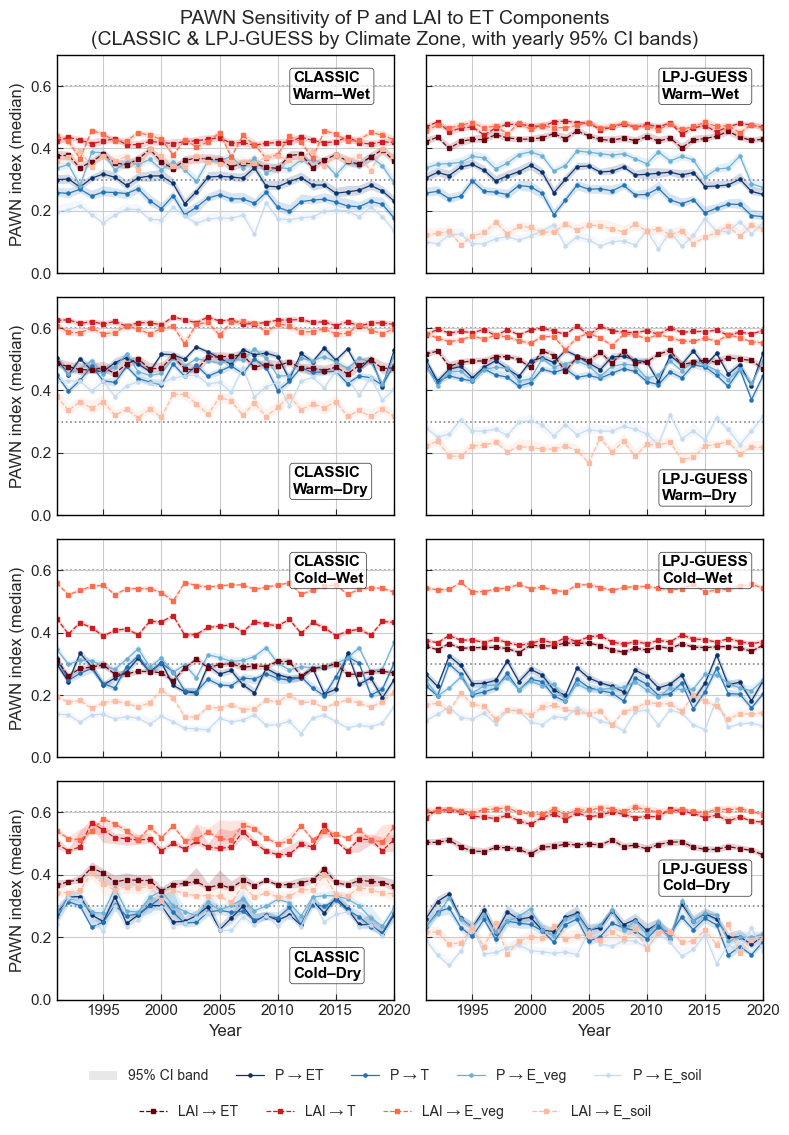

In [59]:
# -*- coding: utf-8 -*-
"""
4×2 图（带逐年CI阴影带）：
每行：一个气候区（HW, HD, CW, CD）
左列：CLASSIC；右列：LPJ-GUESS
曲线同色系，阴影用相同颜色的半透明带
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ========== 1. 读入数据 ==========
main_csv = "./output/30y_pawn/all_30y_pawn_results.csv"
ci_csv   = "./output/30y_pawn/all_bootstrap_30y_results.csv"  # ← 替换为你的逐年CI文件

df = pd.read_csv(main_csv)
ci = pd.read_csv(ci_csv)

df["year"] = df["year"].astype(int)
ci["year"] = ci["year"].astype(int)
df = df[df["input_var"].isin(["precipitation", "lai"])]

# ========== 2. 定义参数 ==========
models = ["CLASSIC", "LPJ-GUESS"]
zones = ["HW", "HD", "CW", "CD"]
label_order = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]
zone_titles = {"HW": "Warm–Wet", "HD": "Warm–Dry", "CW": "Cold–Wet", "CD": "Cold–Dry"}

# 颜色
blues = ["#08306b", "#2171b5", "#6baed6", "#c6dbef"]  # P
reds  = ["#67000d", "#cb181d", "#fb6a4a", "#fcbba1"]  # LAI

label_map_P = {"evapotrans":"P → ET","tran":"P → T","evspsblveg":"P → E_veg","evspsblsoi":"P → E_soil"}
label_map_L = {"evapotrans":"LAI → ET","tran":"LAI → T","evspsblveg":"LAI → E_veg","evspsblsoi":"LAI → E_soil"}

# ========== 3. 样式 ==========
mpl.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
plt.style.use("seaborn-v0_8-whitegrid")

# ========== 4. 画布 ==========
fig, axes = plt.subplots(4, 2, figsize=(8, 12), sharey=True, sharex='col')
plt.subplots_adjust(wspace=0.25, hspace=0.3)

xlim_min, xlim_max = df["year"].min(), df["year"].max()

# 阴影参数
band_alpha = 0.18
band_z     = 1.5
line_z     = 2.0

for i, zone in enumerate(zones):        # 4 行 → zone
    for j, model in enumerate(models):  # 2 列 → model
        ax = axes[i, j]
        sub    = df[(df["model"] == model) & (df["climate_zone"] == zone)]
        ci_sub = ci[(ci["model"] == model) & (ci["climate_zone"] == zone)]

        # ---- P（蓝）----
        for k, out in enumerate(label_order):
            s = sub[(sub["input_var"] == "precipitation") & (sub["output_var"] == out)].sort_values("year")
            if not s.empty:
                ci_s = ci_sub[(ci_sub["input_var"] == "precipitation") &
                              (ci_sub["output_var"] == out)].sort_values("year")
                if {"pawn_ci_lower","pawn_ci_upper"}.issubset(ci_s.columns) and not ci_s.empty:
                    yrs   = ci_s["year"].to_numpy()
                    lower = ci_s["pawn_ci_lower"].to_numpy()
                    upper = ci_s["pawn_ci_upper"].to_numpy()
                    ax.fill_between(yrs, lower, upper, color=blues[k], alpha=band_alpha, linewidth=0, zorder=band_z)

                ax.plot(s["year"], s["pawn_median"],
                        color=blues[k], lw=0.9, marker="o", ms=2.3,
                        alpha=0.95, label=label_map_P[out], zorder=line_z)

        # ---- LAI（红）----
        for k, out in enumerate(label_order):
            s = sub[(sub["input_var"] == "lai") & (sub["output_var"] == out)].sort_values("year")
            if not s.empty:
                ci_s = ci_sub[(ci_sub["input_var"] == "lai") &
                              (ci_sub["output_var"] == out)].sort_values("year")
                if {"pawn_ci_lower","pawn_ci_upper"}.issubset(ci_s.columns) and not ci_s.empty:
                    yrs   = ci_s["year"].to_numpy()
                    lower = ci_s["pawn_ci_lower"].to_numpy()
                    upper = ci_s["pawn_ci_upper"].to_numpy()
                    ax.fill_between(yrs, lower, upper, color=reds[k], alpha=band_alpha, linewidth=0, zorder=band_z)

                ax.plot(s["year"], s["pawn_median"],
                        color=reds[k], lw=0.9, marker="s", ms=2.3,
                        alpha=0.95, linestyle="--", label=label_map_L[out], zorder=line_z)

        # ---- 坐标轴样式 ----
        ax.set_xlim(xlim_min, xlim_max)
        ax.set_ylim(0, 0.7)                    # 固定 y 范围
        ax.set_yticks(np.arange(0, 0.71, 0.2)) # 0.0~0.8 间隔 0.2
        ax.tick_params(direction="in", length=4, width=0.8)
        for spine in ax.spines.values():
            spine.set_color("black"); spine.set_linewidth(1.0)

        # y 轴
        if j == 0:
            ax.set_ylabel("PAWN index (median)")   # 若画的是 PAWN，可改成 "PAWN index (median)"

        # x 轴
        if i == 3:
            ax.set_xlabel("Year")
        else:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)

        # ---- 标注（保持你原来的位置不变）----
        label_pos = {
            ("CLASSIC",   "HW"): (0.7,  0.8),
            ("CLASSIC",   "HD"): (0.70, 0.1),
            ("CLASSIC",   "CW"): (0.7,  0.8),
            ("CLASSIC",   "CD"): (0.70, 0.1),
            ("LPJ-GUESS", "HW"): (0.7,  0.8),
            ("LPJ-GUESS", "HD"): (0.70, 0.07),
            ("LPJ-GUESS", "CW"): (0.7,  0.8),
            ("LPJ-GUESS", "CD"): (0.70, 0.5),
        }
        xfrac, yfrac = label_pos.get((model, zone), (0.15, 0.8))
        ax.text(xfrac, yfrac, f"{model}\n{zone_titles.get(zone, zone)}",
                transform=ax.transAxes, fontsize=11, fontweight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=0.6, alpha=0.7))

        # ---- 参考线 ----
        for yref in [0.3, 0.6]:
            ax.axhline(y=yref, color="dimgray", lw=1.2, ls=":", alpha=0.8, zorder=0)

# ========= 6. 图例 =========
# ========= 6. 图例（分两行显示） =========
handles_P = [Line2D([], [], color=blues[k], lw=0.9, marker="o", ms=2.3) for k in range(4)]
handles_L = [Line2D([], [], color=reds[k],  lw=0.9, marker="s", ms=2.3, linestyle="--") for k in range(4)]
band_patch = Patch(facecolor="gray", alpha=band_alpha, label="95% CI band")

labels_P = ["P → ET", "P → T", "P → E_veg", "P → E_soil"]
labels_L = ["LAI → ET", "LAI → T", "LAI → E_veg", "LAI → E_soil"]

# 第一行：P sensitivity
fig.legend([band_patch] + handles_P,
           ["95% CI band"] + labels_P,
           loc="lower center", ncol=5, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, 0.055))

# 第二行：LAI sensitivity
fig.legend(handles_L, labels_L,
           loc="lower center", ncol=4, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, 0.025))

# ========= 7. 总标题 =========
fig.suptitle("PAWN Sensitivity of P and LAI to ET Components\n(CLASSIC & LPJ-GUESS by Climate Zone, with yearly 95% CI bands)",
             fontsize=14, y=0.96)
plt.tight_layout(rect=[0, 0.09, 1, 0.98])
plt.show()

